
# 02 · Análisis Exploratorio de Datos (EDA)
**TFM: Análisis y Predicción de la Extorsión en Colombia**

Este script realiza el análisis descriptivo y exploratorio sobre los datasets Silver
y el consolidado Gold, generando las ilustraciones que sustentan las secciones
6, 7 y 8 del documento final.

**Inputs**:
- `datos/silver/*.csv` — datasets individuales limpios
- `datos/gold/consolidado_modelado.csv` — dataset de modelado (2020–2025)

**Outputs**:
- `outputs/eda/graficos/*.png` — ilustraciones 01–20 (300 DPI)


## 1. Configuración Inicial


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFECV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
import warnings
import os

warnings.filterwarnings('ignore')

# ── Rutas ────────────────────────────────────────────────────────────────────
SILVER_PATH  = 'datos/silver'
GOLD_PATH    = 'datos/gold'
GRAFICOS_PATH = 'outputs/eda/graficos'

os.makedirs(GRAFICOS_PATH, exist_ok=True)

# ── Estilo visual ─────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'figure.dpi':       300,
    'font.size':        11,
    'font.family':      'DejaVu Sans',
    'axes.grid':        True,
    'grid.alpha':       0.3,
})

print("[OK] Configuración lista")
print(f"     Gráficos → {GRAFICOS_PATH}/")

[OK] Configuración lista
     Gráficos → outputs/eda/graficos/



## 2. Carga de Datos Silver


In [2]:
df_extorsion   = pd.read_csv(f'{SILVER_PATH}/extorsion_silver.csv',   parse_dates=['fecha_hecho'])
df_poblacion   = pd.read_csv(f'{SILVER_PATH}/poblacion_silver.csv')
df_homicidio   = pd.read_csv(f'{SILVER_PATH}/homicidio_silver.csv',   parse_dates=['fecha_hecho'])
df_hurto       = pd.read_csv(f'{SILVER_PATH}/hurto_silver.csv',       parse_dates=['fecha_hecho'])
df_terrorismo  = pd.read_csv(f'{SILVER_PATH}/terrorismo_silver.csv',  parse_dates=['fecha_hecho'])
df_estupef     = pd.read_csv(f'{SILVER_PATH}/estupefacientes_silver.csv')
df_coca        = pd.read_csv(f'{SILVER_PATH}/coca_silver.csv')
df_cobertura   = pd.read_csv(f'{SILVER_PATH}/cobertura_movil_silver.csv')
df_pib         = pd.read_csv(f'{SILVER_PATH}/pib_silver.csv')

# Dataset de modelado Gold (para ilustraciones 18–20)
df_gold = pd.read_csv(f'{GOLD_PATH}/consolidado_modelado.csv')

print("Datasets cargados:")
for name, df in [('Extorsion', df_extorsion), ('Poblacion', df_poblacion),
                 ('Homicidio', df_homicidio), ('Hurto', df_hurto),
                 ('Terrorismo', df_terrorismo), ('Estupefacientes', df_estupef),
                 ('Coca', df_coca), ('Cobertura', df_cobertura), ('PIB', df_pib),
                 ('Gold (modelado)', df_gold)]:
    print(f"  {name:<20} {len(df):>8,} registros")

Datasets cargados:
  Extorsion             122,457 registros
  Poblacion              53,856 registros
  Homicidio             335,581 registros
  Hurto                 632,758 registros
  Terrorismo             14,897 registros
  Estupefacientes      1,928,185 registros
  Coca                    7,337 registros
  Cobertura             407,281 registros
  PIB                    16,302 registros
  Gold (modelado)        16,869 registros



## 3. Serie Temporal de Extorsión

**Ilustración 1**: Tendencia anual de denuncias por extorsión (2000–2025)
**Ilustración 2**: Tendencia mensual reciente (2023–2025, excluye Nov–Dic)


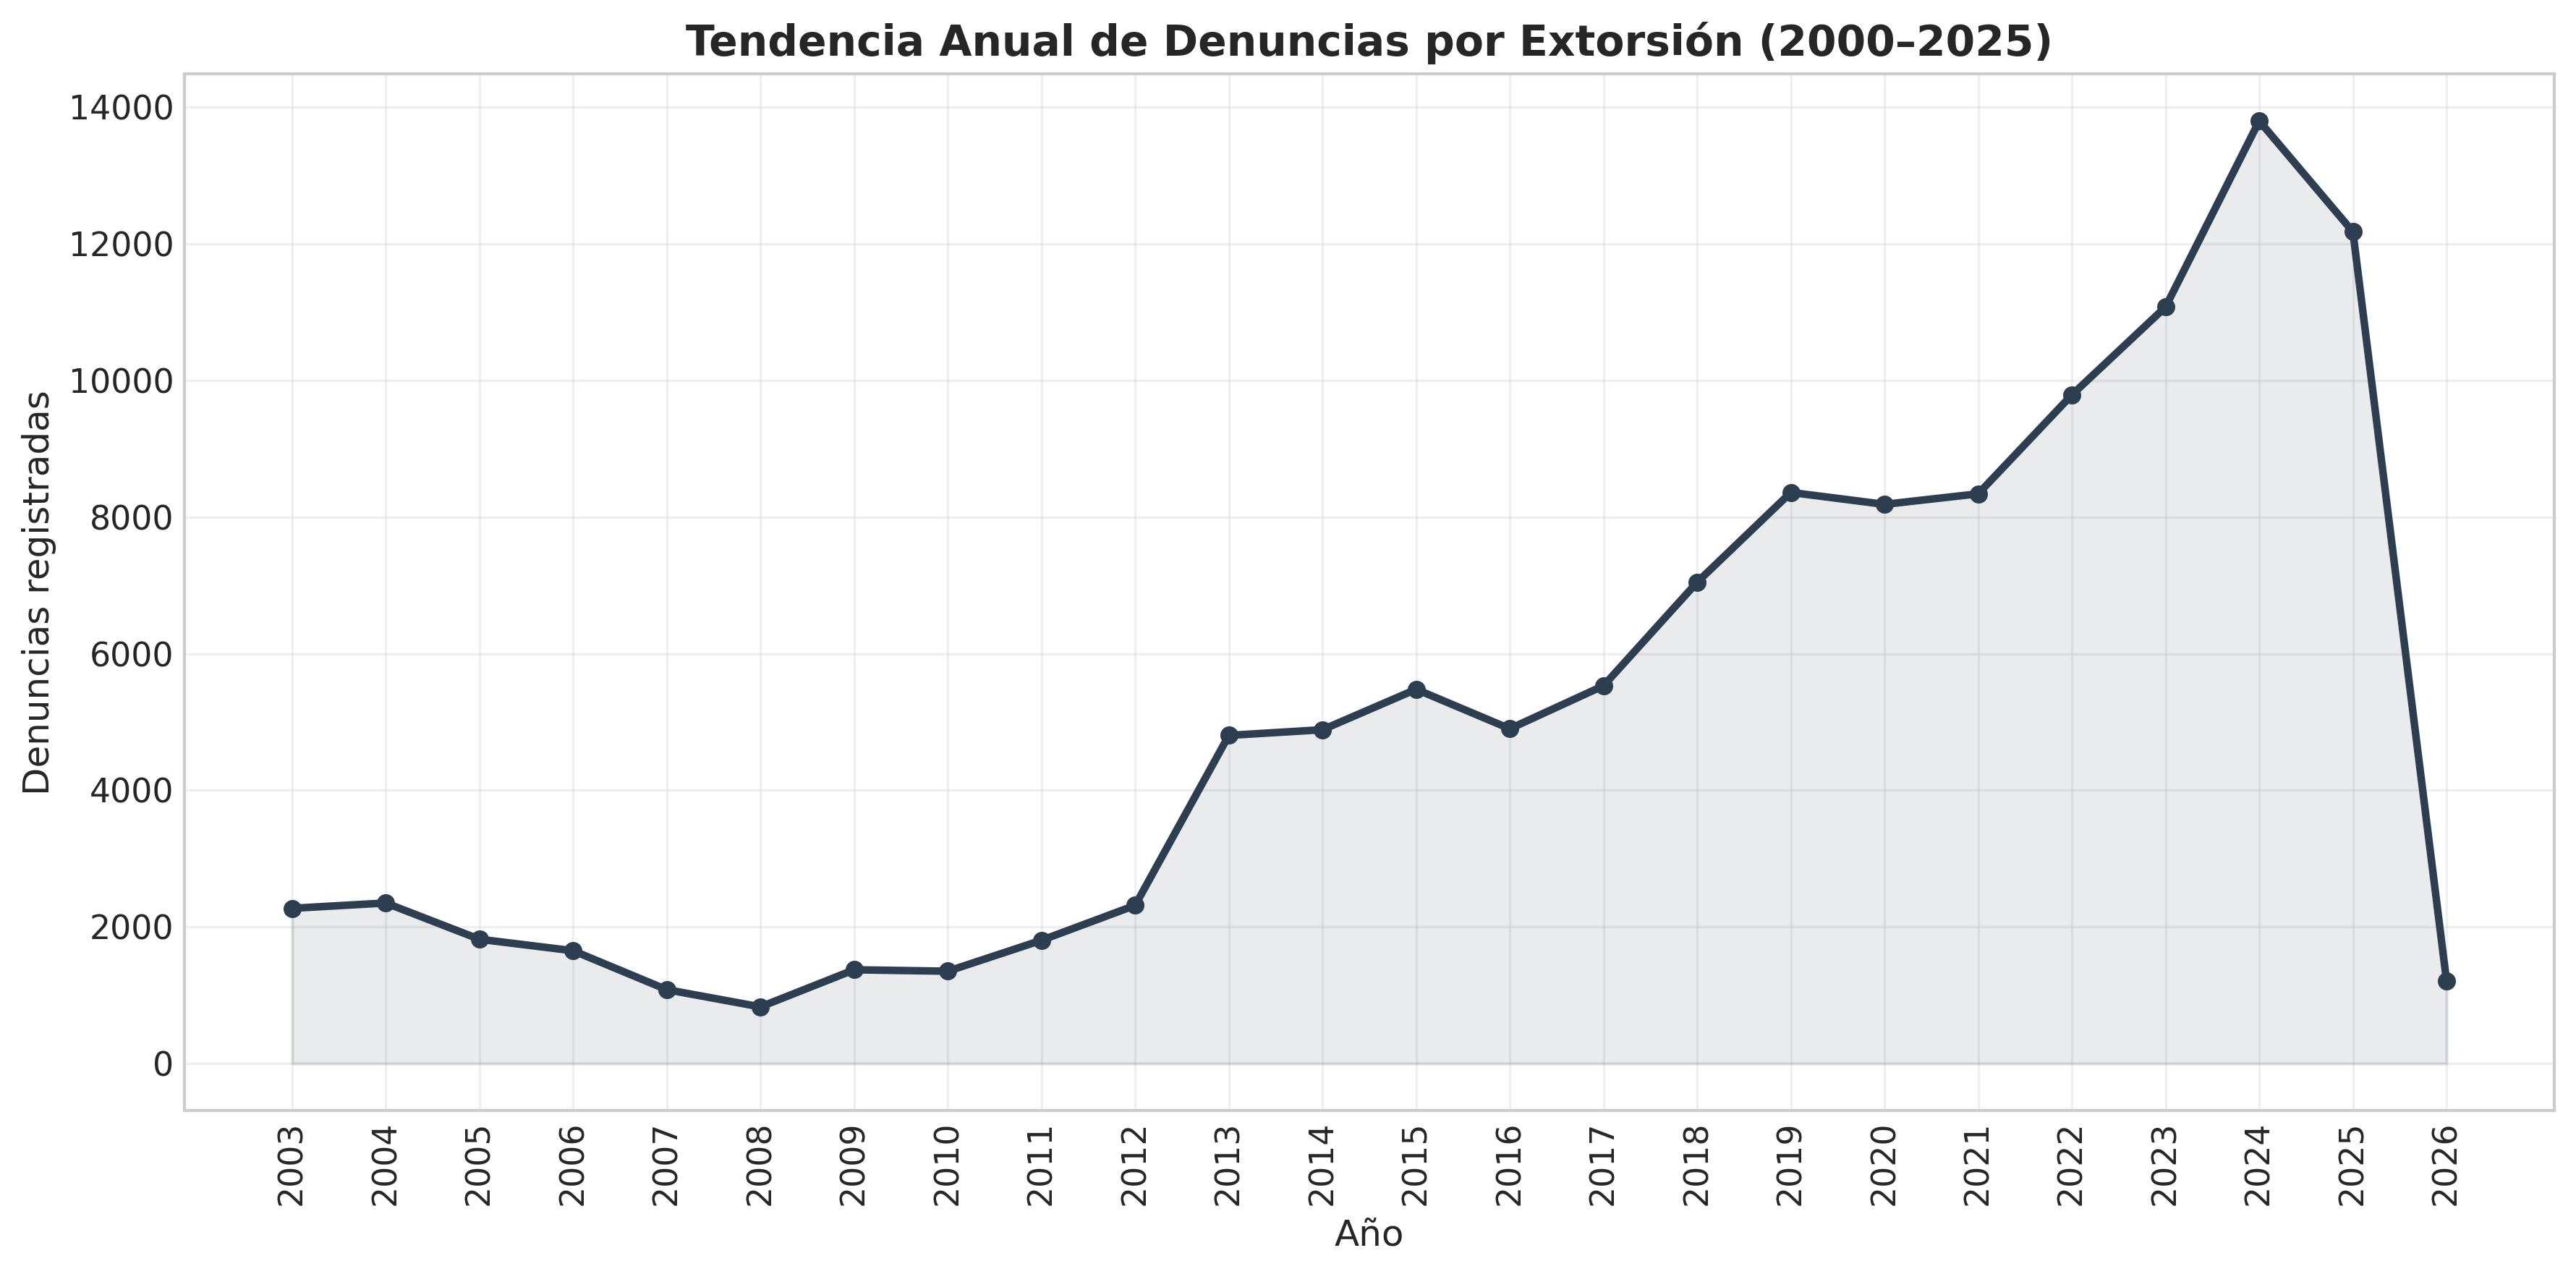

Guardado: 01_extorsion_tendencia_anual.png


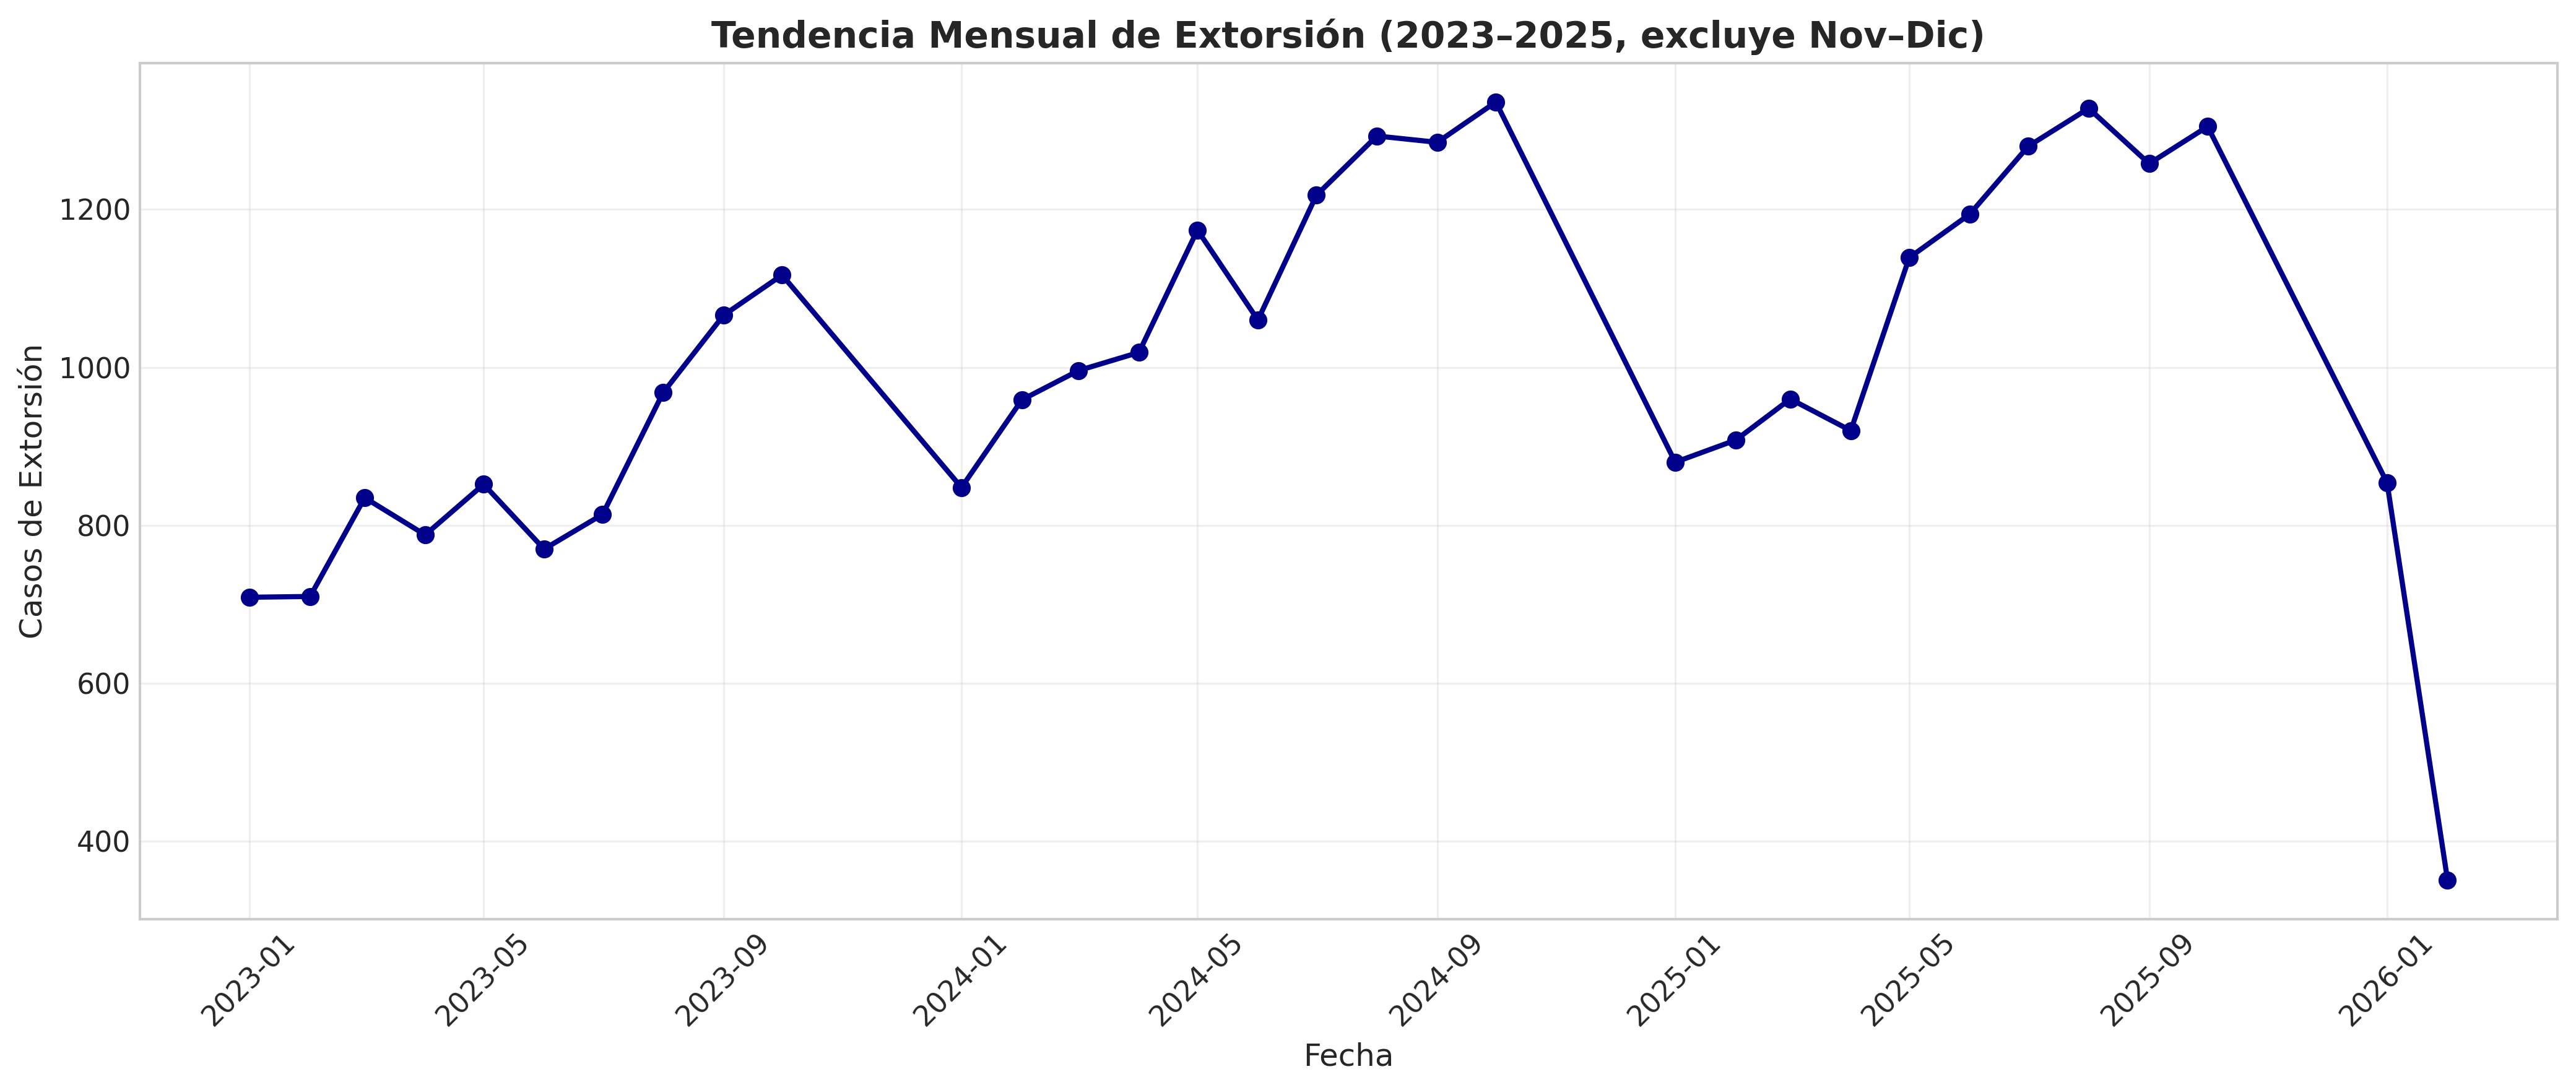

Guardado: 02_extorsion_tendencia_mensual.png


In [3]:
# ── Ilustración 1: Tendencia anual ──────────────────────────────────────────
df_ext = df_extorsion.copy()
df_ext['ano'] = pd.to_numeric(df_ext['ano'], errors='coerce')
df_ext['cantidad'] = pd.to_numeric(df_ext['cantidad'], errors='coerce').fillna(0)

df_anual = df_ext[df_ext['ano'] >= 2000].groupby('ano')['cantidad'].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df_anual['ano'], df_anual['cantidad'], color='#2c3e50', linewidth=2.5, marker='o', markersize=5)
ax.fill_between(df_anual['ano'], df_anual['cantidad'], alpha=0.1, color='#2c3e50')
ax.set_xticks(df_anual['ano'])
ax.set_xticklabels(df_anual['ano'], rotation=90)
ax.set_title('Tendencia Anual de Denuncias por Extorsión (2000–2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('Denuncias registradas', fontsize=12)
plt.tight_layout()
plt.savefig(f'{GRAFICOS_PATH}/01_extorsion_tendencia_anual.png', dpi=300, bbox_inches='tight')
plt.show()
print("Guardado: 01_extorsion_tendencia_anual.png")

# ── Ilustración 2: Tendencia mensual reciente ────────────────────────────────
df_mensual = df_extorsion[
    (df_extorsion['ano'] >= 2023) & (~df_extorsion['mes'].isin([11, 12]))
].copy()
df_mensual['periodo'] = pd.to_datetime(
    df_mensual['ano'].astype(str) + '-' + df_mensual['mes'].astype(str).str.zfill(2) + '-01')
df_mensual_agg = df_mensual.groupby('periodo')['cantidad'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_mensual_agg['periodo'], df_mensual_agg['cantidad'], color='darkblue', linewidth=2, marker='o')
ax.set_title('Tendencia Mensual de Extorsión (2023–2025, excluye Nov–Dic)', fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Casos de Extorsión', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{GRAFICOS_PATH}/02_extorsion_tendencia_mensual.png', dpi=300, bbox_inches='tight')
plt.show()
print("Guardado: 02_extorsion_tendencia_mensual.png")


## 4. Distribución Geográfica por Departamento

**Ilustración 3**: Top departamentos por casos totales (2018–2025)
**Ilustración 4**: Boxplot de distribución anual por departamento


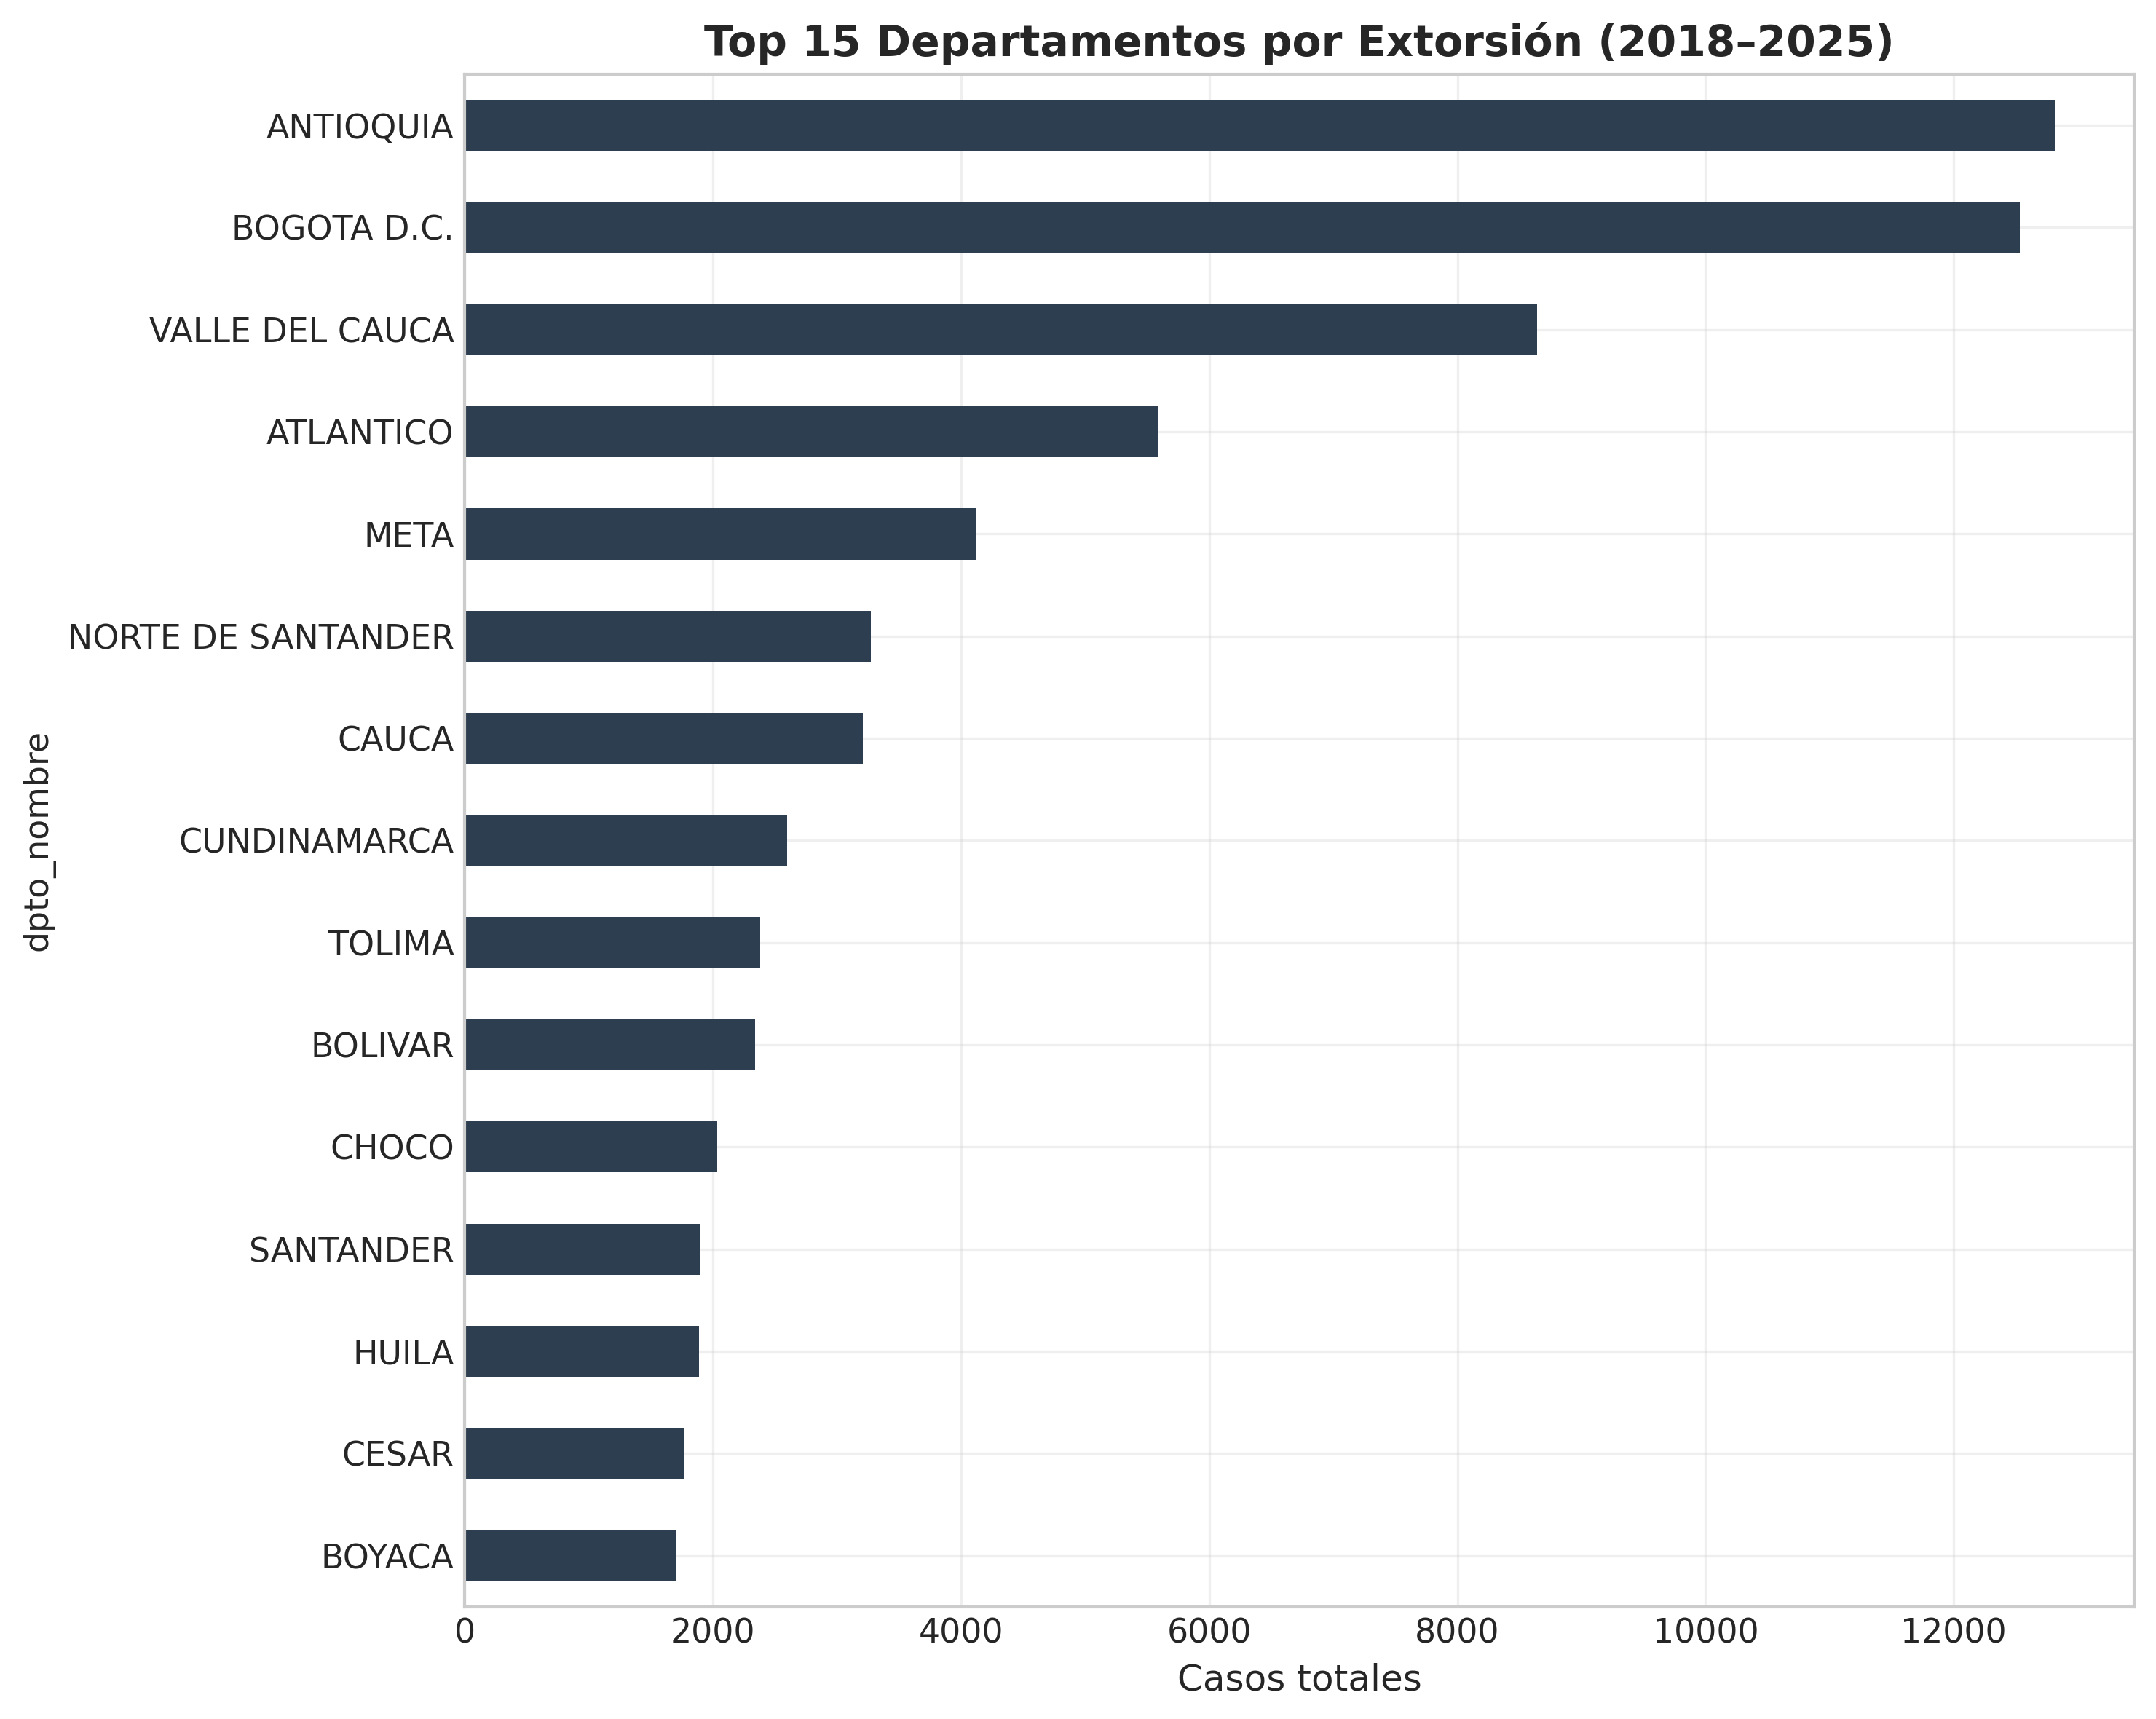

Guardado: 03_extorsion_top_departamentos.png


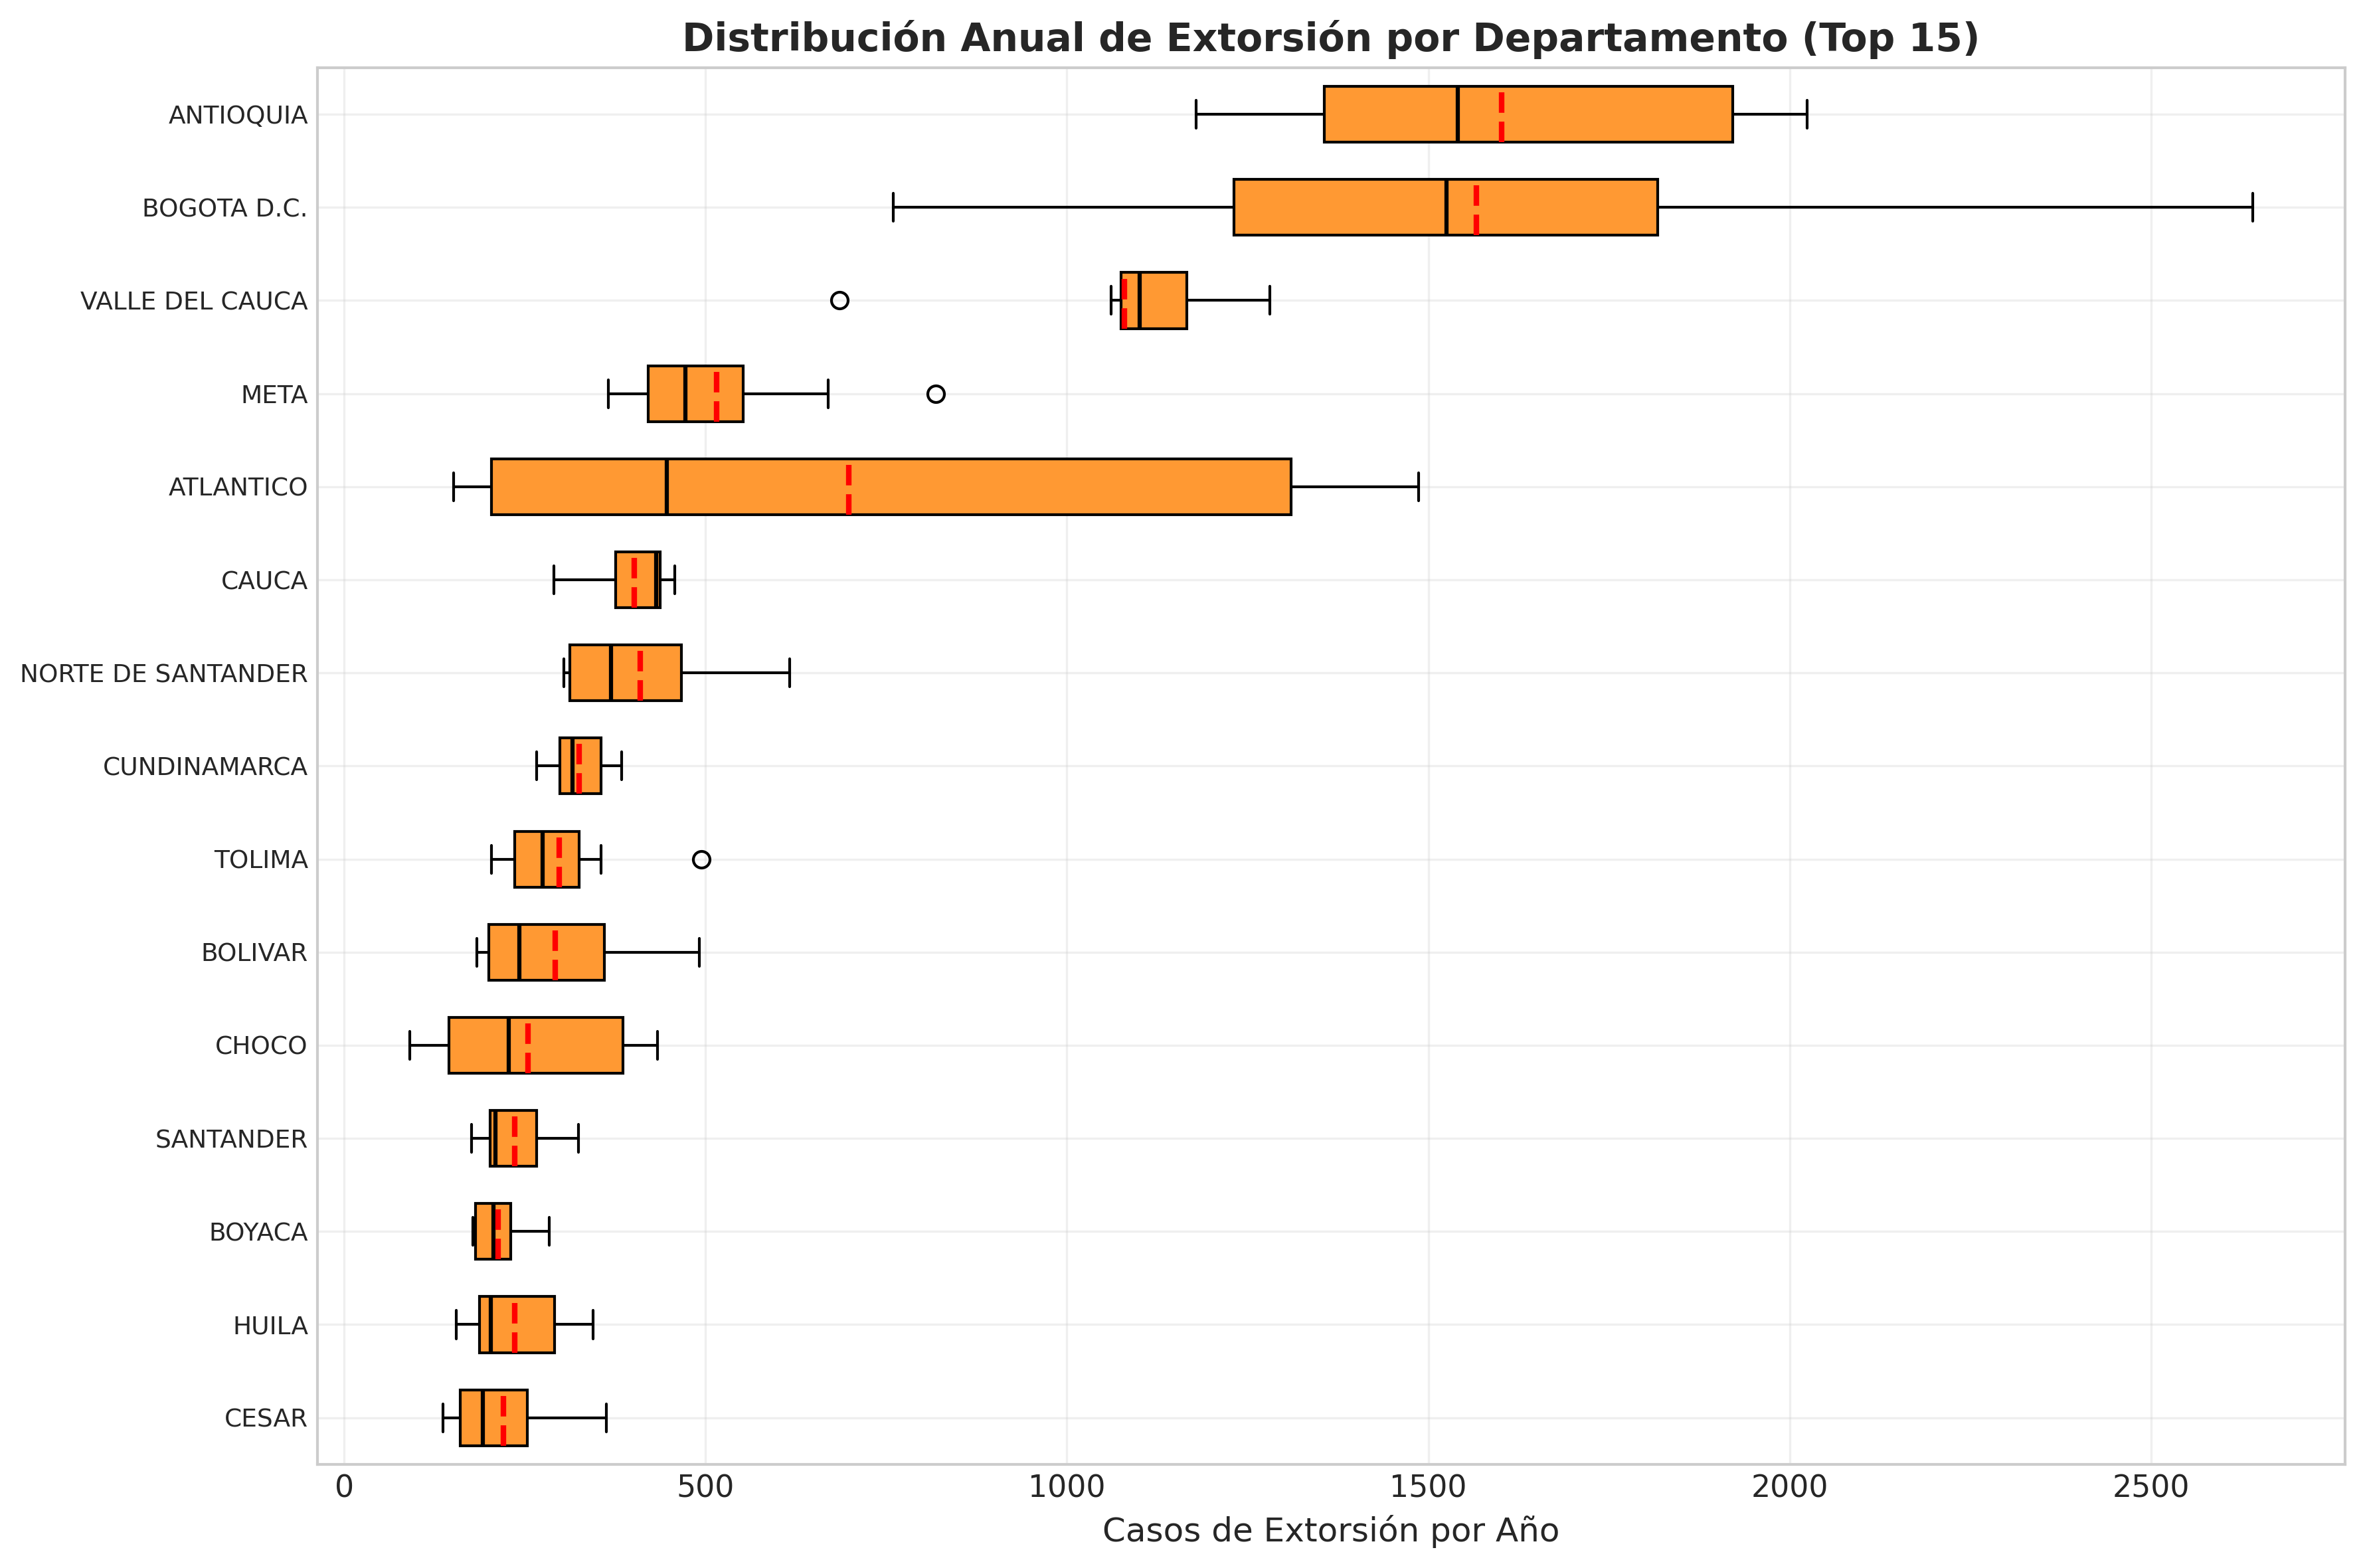

Guardado: 04_extorsion_boxplot_departamentos.png


In [4]:
ANIO_INI, ANIO_FIN = 2018, 2025
df_ext_geo = df_extorsion.query("@ANIO_INI <= ano <= @ANIO_FIN").copy()
df_ext_geo['cantidad'] = pd.to_numeric(df_ext_geo['cantidad'], errors='coerce').fillna(0)

# ── Ilustración 3: Top departamentos (barras horizontales) ───────────────────
top_dptos = df_ext_geo.groupby('dpto_nombre')['cantidad'].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
top_dptos.tail(15).plot(kind='barh', ax=ax, color='#2c3e50')
ax.set_title(f'Top 15 Departamentos por Extorsión ({ANIO_INI}–{ANIO_FIN})', fontsize=14, fontweight='bold')
ax.set_xlabel('Casos totales', fontsize=12)
plt.tight_layout()
plt.savefig(f'{GRAFICOS_PATH}/03_extorsion_top_departamentos.png', dpi=300, bbox_inches='tight')
plt.show()
print("Guardado: 03_extorsion_top_departamentos.png")

# ── Ilustración 4: Boxplot por departamento ──────────────────────────────────
df_dpto_ano = df_ext_geo.groupby(['dpto_nombre', 'ano'])['cantidad'].sum().reset_index()
top15_names = df_dpto_ano.groupby('dpto_nombre')['cantidad'].sum().nlargest(15).index
df_top15 = df_dpto_ano[df_dpto_ano['dpto_nombre'].isin(top15_names)]

# Ordenar por mediana
orden = (df_top15.groupby('dpto_nombre')['cantidad']
         .median().sort_values().index.tolist())
data_box = [df_top15[df_top15['dpto_nombre'] == d]['cantidad'].values for d in orden]

fig, ax = plt.subplots(figsize=(12, 8))
bp = ax.boxplot(data_box, vert=False, patch_artist=True, widths=0.6,
                showmeans=True, meanline=True,
                boxprops=dict(facecolor='#FF9933', edgecolor='black'),
                medianprops=dict(color='black', linewidth=1.5),
                meanprops=dict(color='red', linewidth=2))
ax.set_yticklabels(orden, fontsize=9)
ax.set_xlabel('Casos de Extorsión por Año', fontsize=12)
ax.set_title('Distribución Anual de Extorsión por Departamento (Top 15)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{GRAFICOS_PATH}/04_extorsion_boxplot_departamentos.png', dpi=300, bbox_inches='tight')
plt.show()
print("Guardado: 04_extorsion_boxplot_departamentos.png")


## 5. Contexto Demográfico

**Ilustración 5**: Evolución población urbana vs. rural (proyecciones DANE 2020–2035)


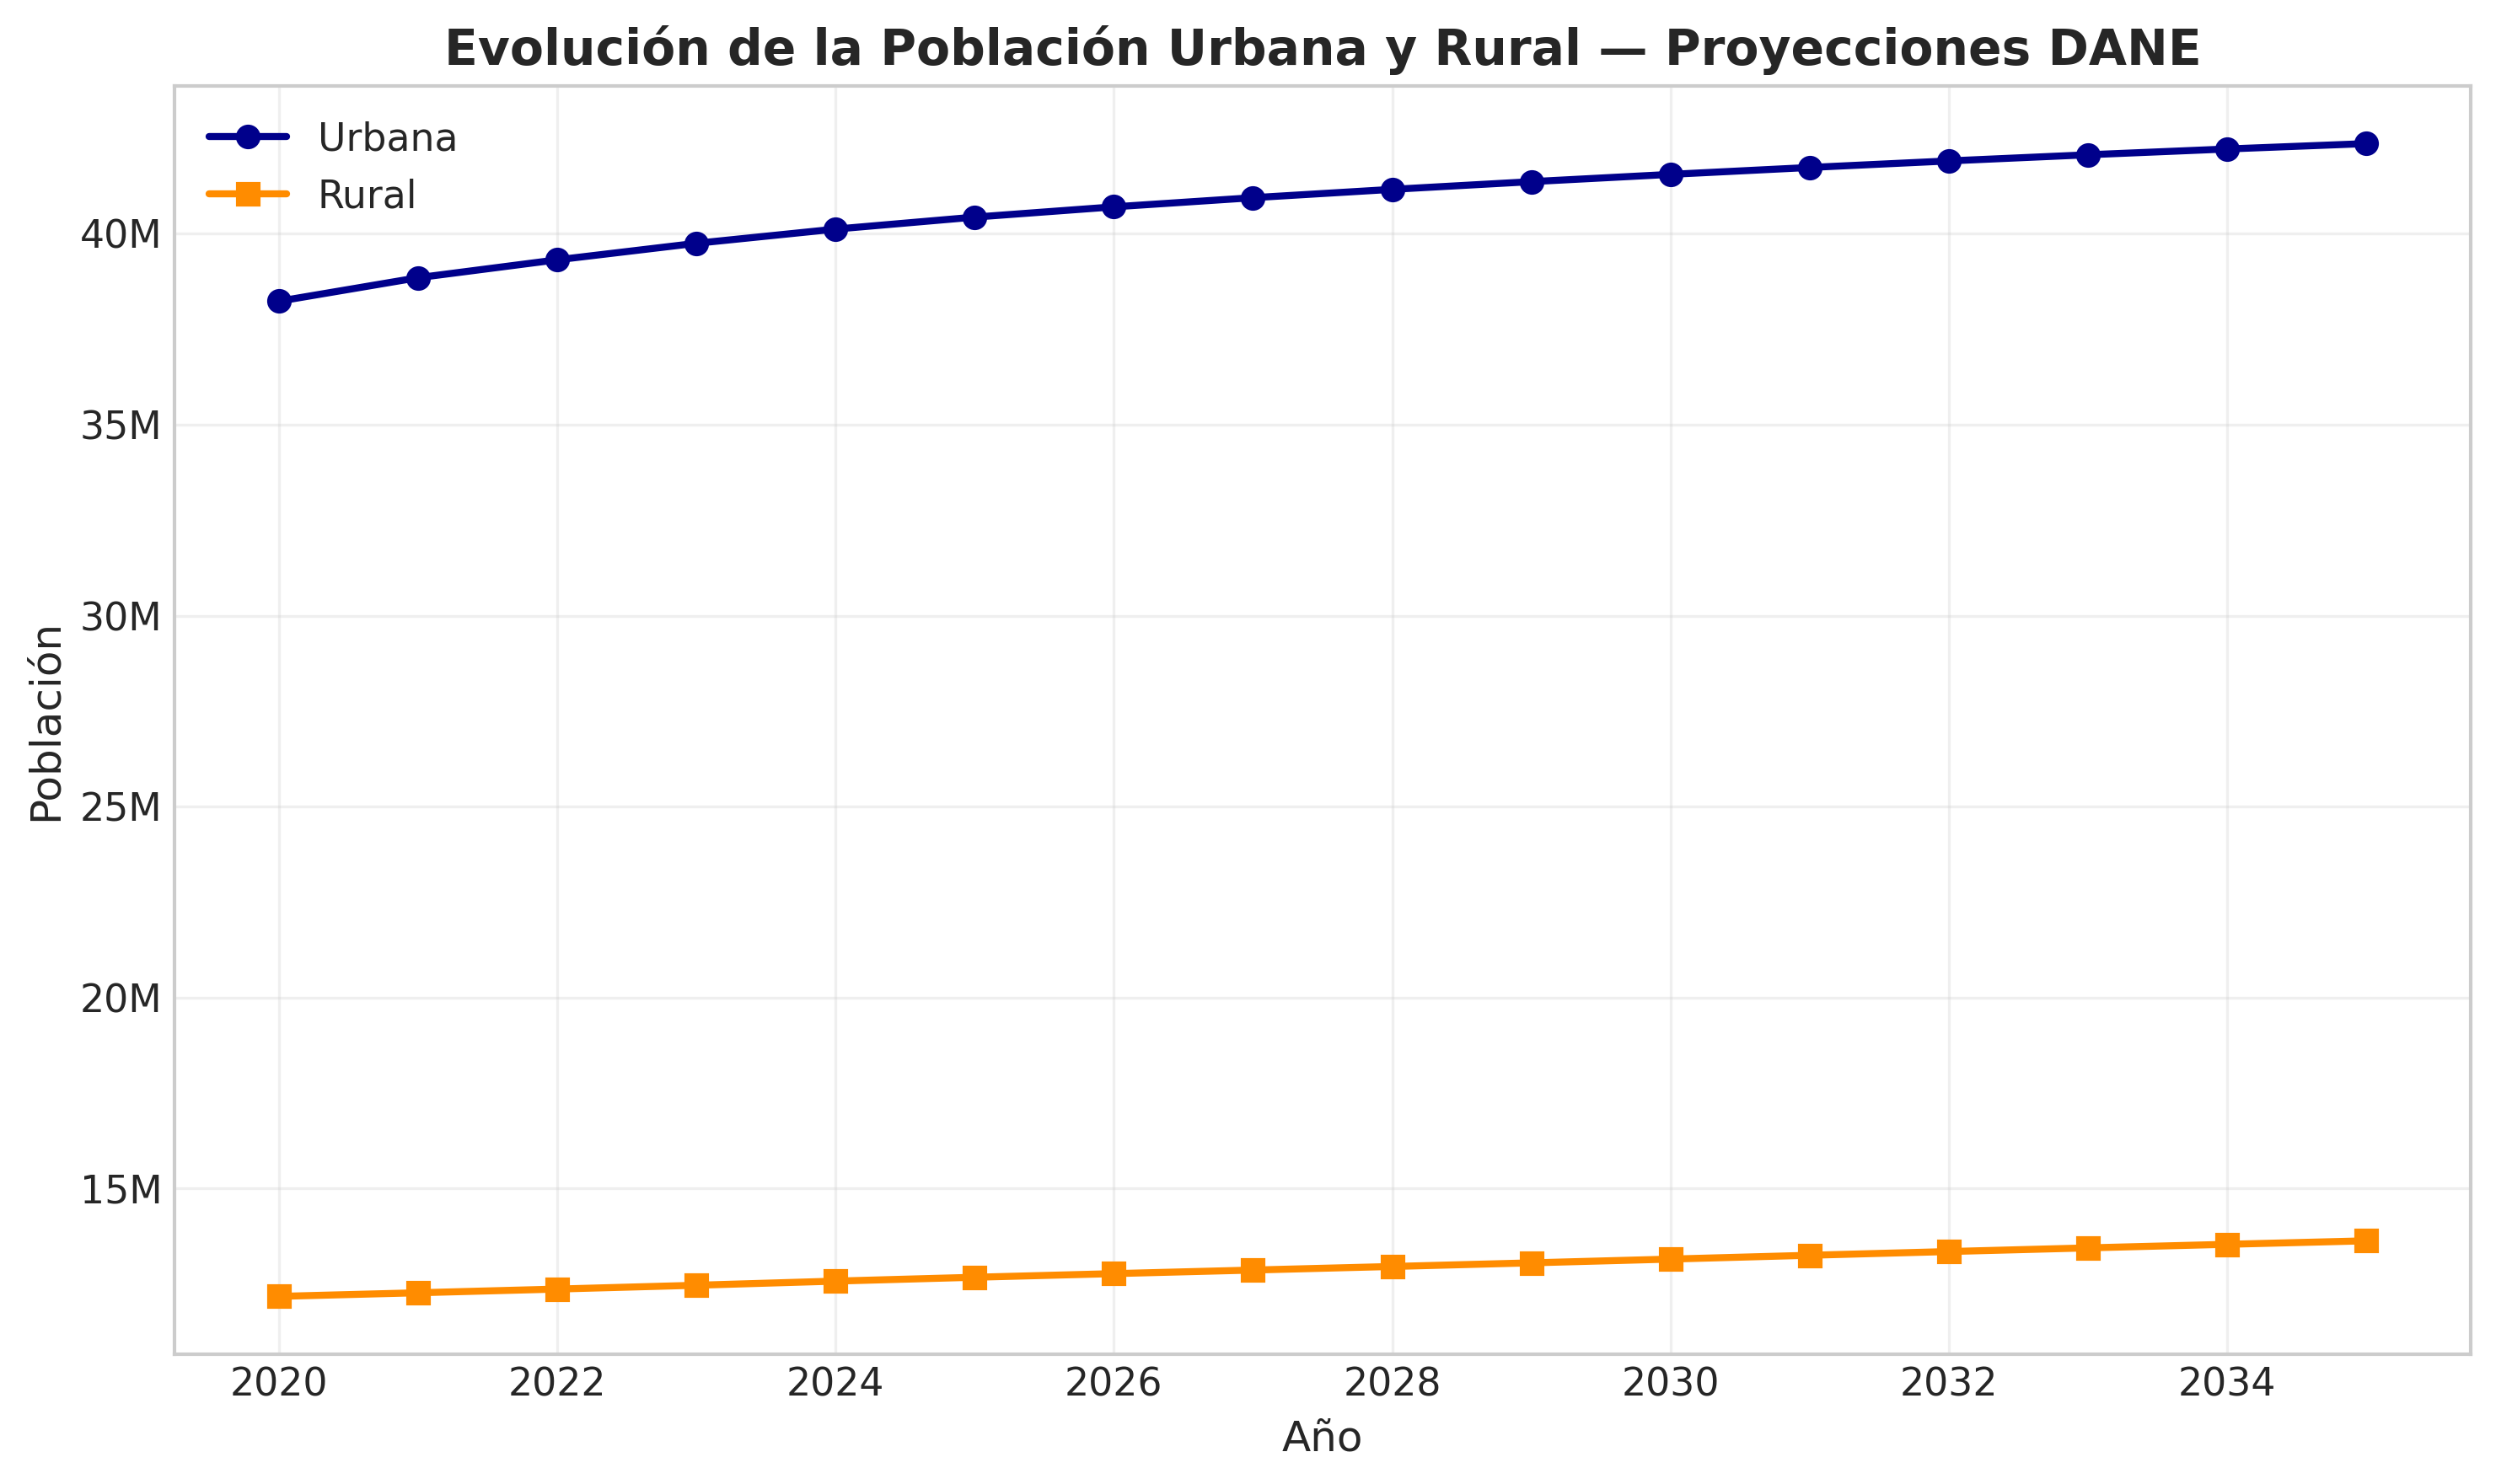

Guardado: 06_poblacion_urbana_rural.png


In [5]:
df_pob_ur = df_poblacion[df_poblacion['tipo_area'].isin(['Urbana', 'Rural'])]
df_pob_grouped = df_pob_ur.groupby(['ano', 'tipo_area'])['poblacion'].sum().unstack()

fig, ax = plt.subplots(figsize=(10, 6))
df_pob_grouped['Urbana'].plot(kind='line', marker='o', ax=ax, label='Urbana', color='darkblue', linewidth=2)
df_pob_grouped['Rural'].plot(kind='line', marker='s', ax=ax, label='Rural', color='darkorange', linewidth=2)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
ax.set_title('Evolución de la Población Urbana y Rural — Proyecciones DANE', fontsize=14, fontweight='bold')
ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('Población', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig(f'{GRAFICOS_PATH}/06_poblacion_urbana_rural.png', dpi=300, bbox_inches='tight')
plt.show()
print("Guardado: 06_poblacion_urbana_rural.png")


## 6. Análisis Comparativo de Delitos

**Ilustración 6**: Comparación temporal de extorsión vs. homicidio vs. hurto (2018–2025)


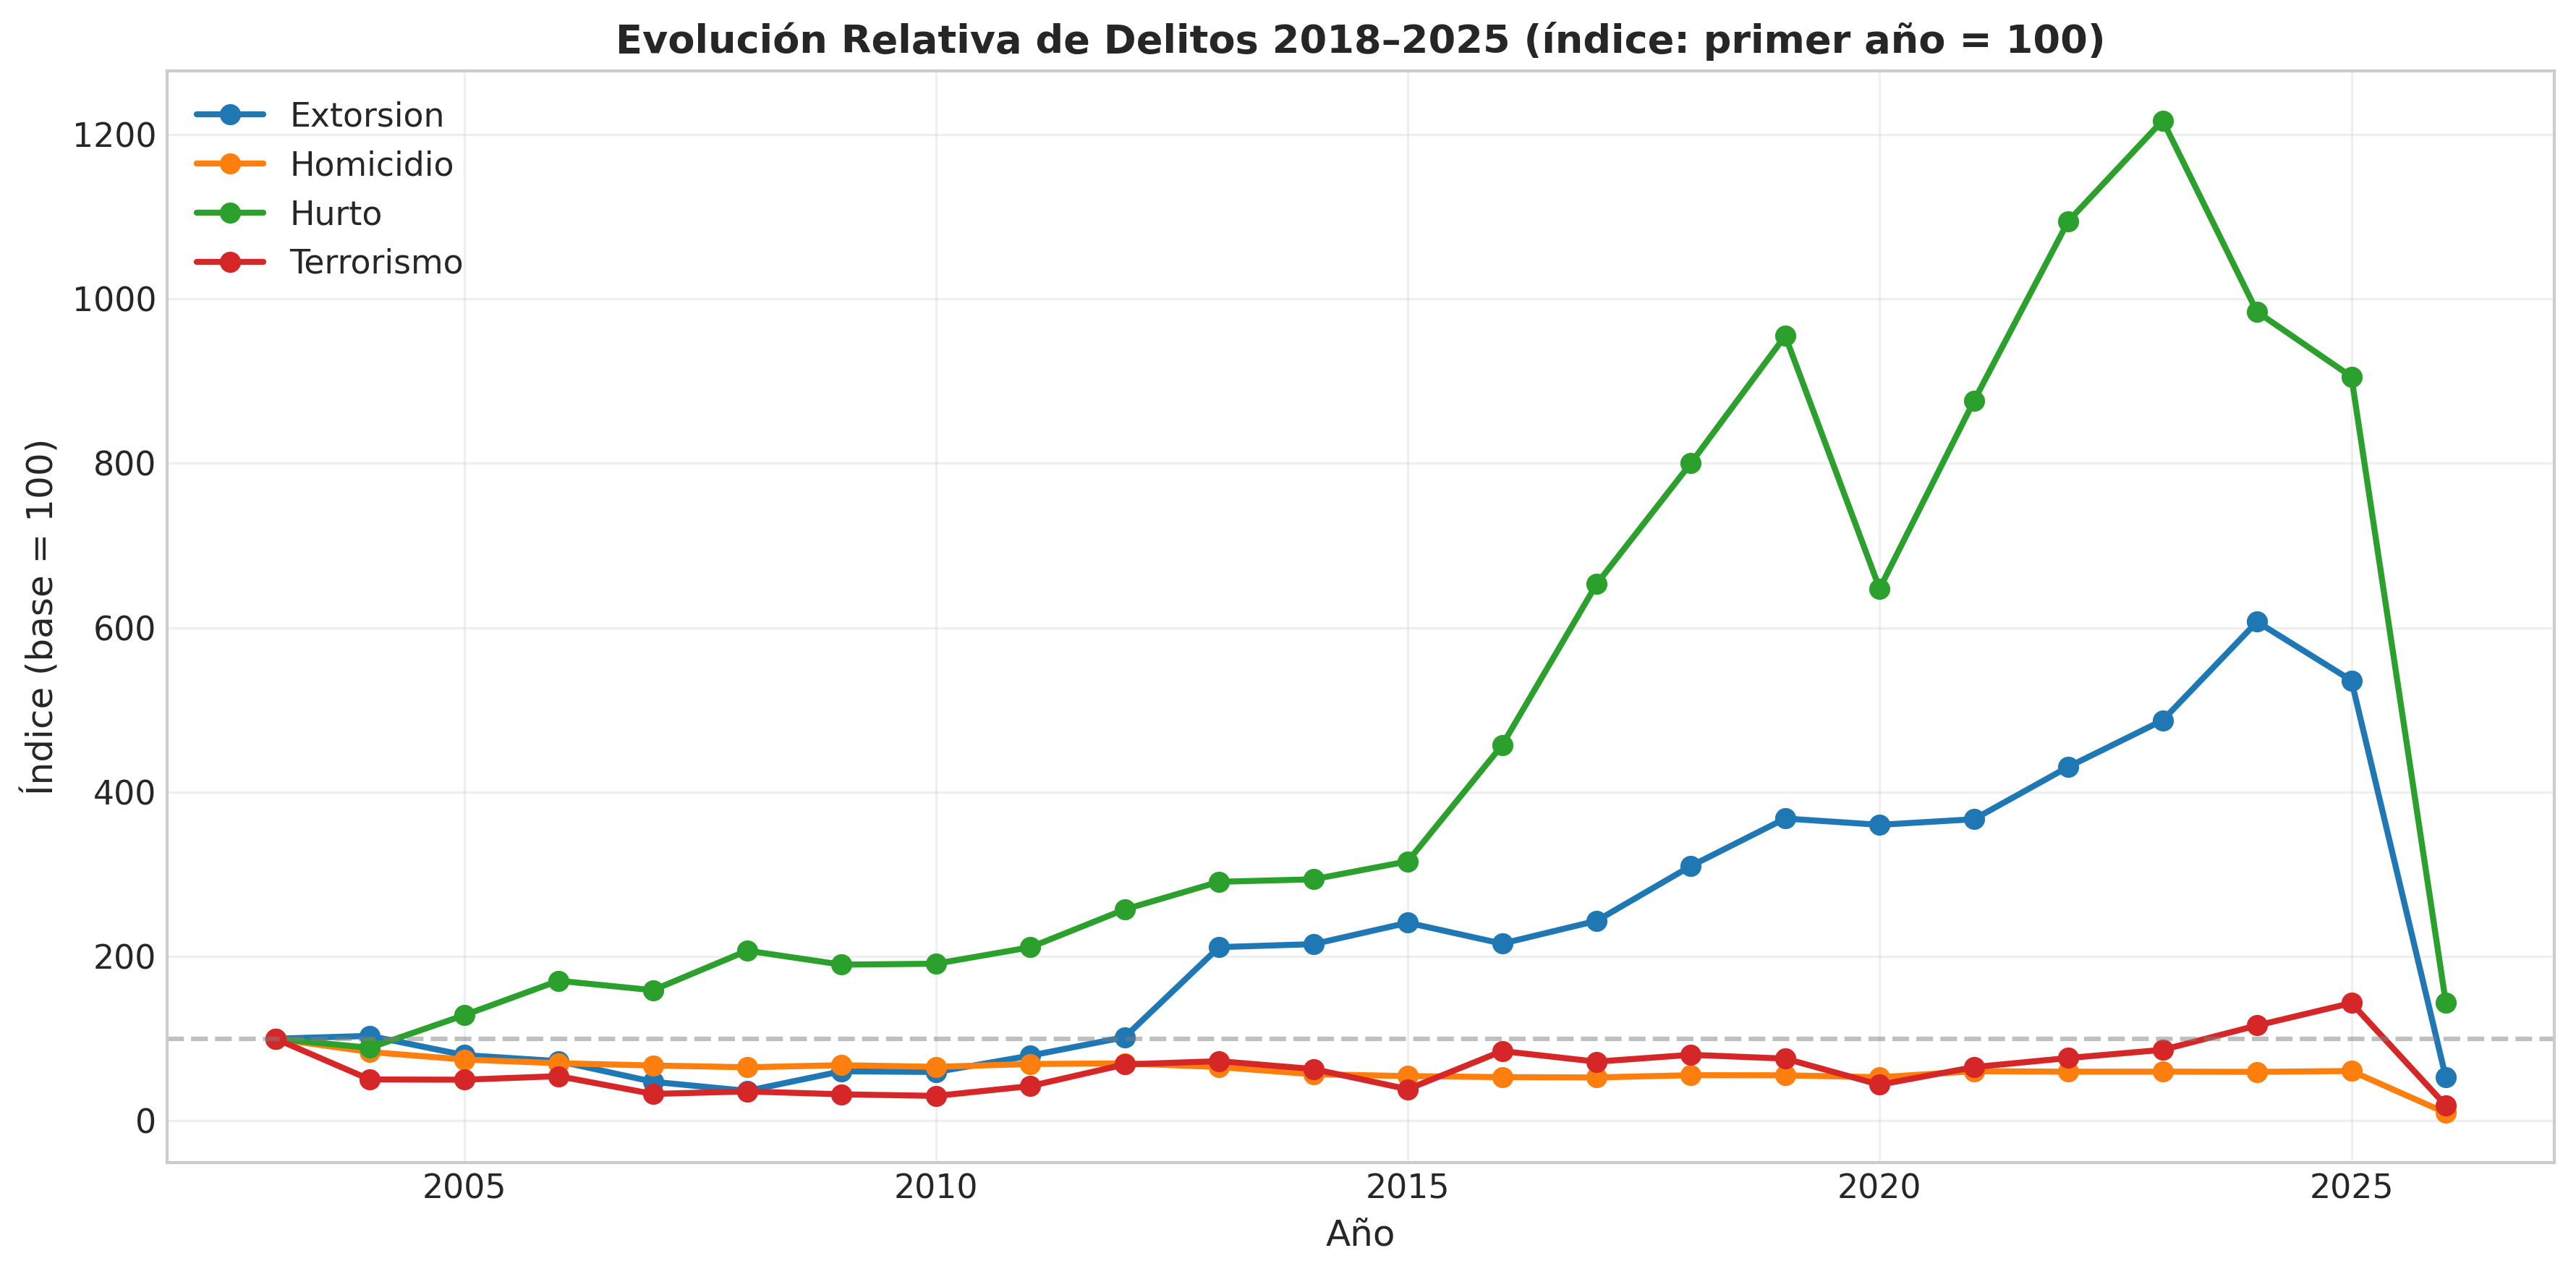

Guardado: 05_comparacion_delitos_temporal.png


In [9]:
def agg_anual(df, col_cantidad='cantidad', col_ano='ano', label='total'):
    return (df[df['ano'] >= 2018 & (df['ano'] <= 2025)]
            .groupby(col_ano)[col_cantidad].sum()
            .rename(label))

s_ext  = agg_anual(df_extorsion,  label='Extorsion')
s_hom  = agg_anual(df_homicidio,  label='Homicidio')
s_hur  = agg_anual(df_hurto,      label='Hurto')
s_ter  = agg_anual(df_terrorismo, label='Terrorismo')

df_comp = pd.concat([s_ext, s_hom, s_hur, s_ter], axis=1).dropna()

fig, ax = plt.subplots(figsize=(12, 6))
for col, color in zip(df_comp.columns, ['#2c3e50', '#e74c3c', '#3498db', '#e67e22']):
    # Normalizar a índice 100 en primer año para comparación relativa
    serie = df_comp[col] / df_comp[col].iloc[0] * 100
    ax.plot(df_comp.index, serie, label=col, linewidth=2, marker='o')
ax.axhline(100, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Evolución Relativa de Delitos 2018–2025 (índice: primer año = 100)', fontsize=13, fontweight='bold')
ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('Índice (base = 100)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig(f'{GRAFICOS_PATH}/05_comparacion_delitos_temporal.png', dpi=300, bbox_inches='tight')
plt.show()
print("Guardado: 05_comparacion_delitos_temporal.png")


## 7. Análisis de Narcotráfico y Coca

**Ilustración 7**: Evolución de incautaciones de estupefacientes
**Ilustración 8**: Coca (hectáreas) vs. extorsión — correlación departamental


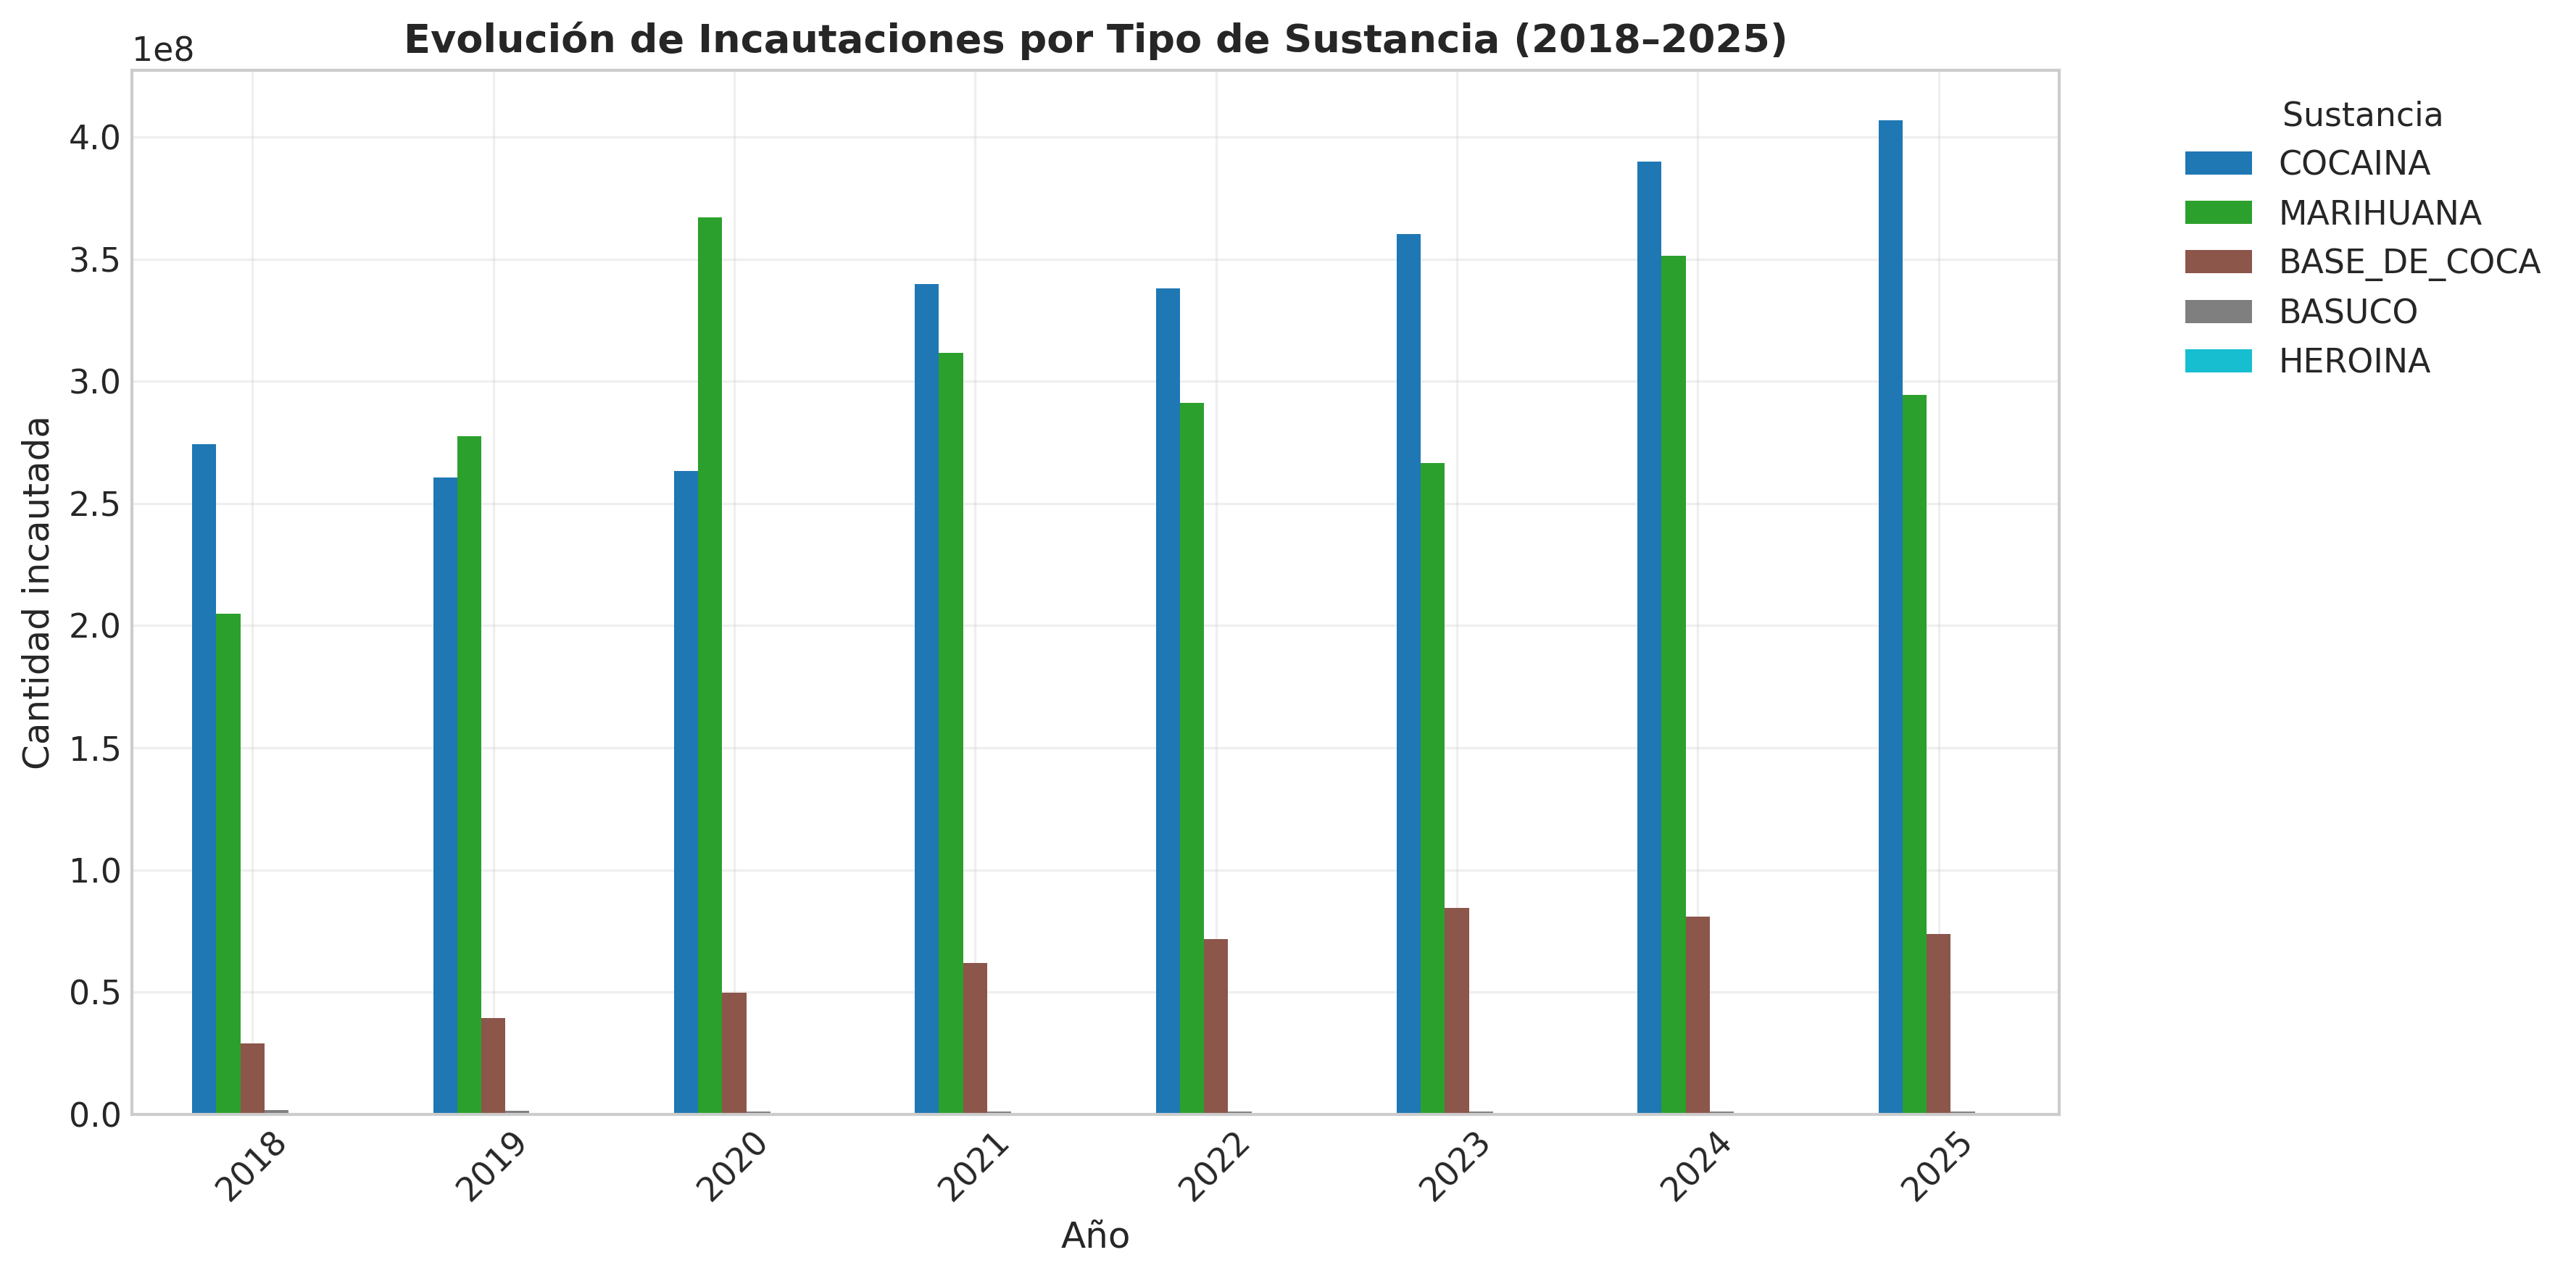

Guardado: 07_narcotrafico_evolucion.png


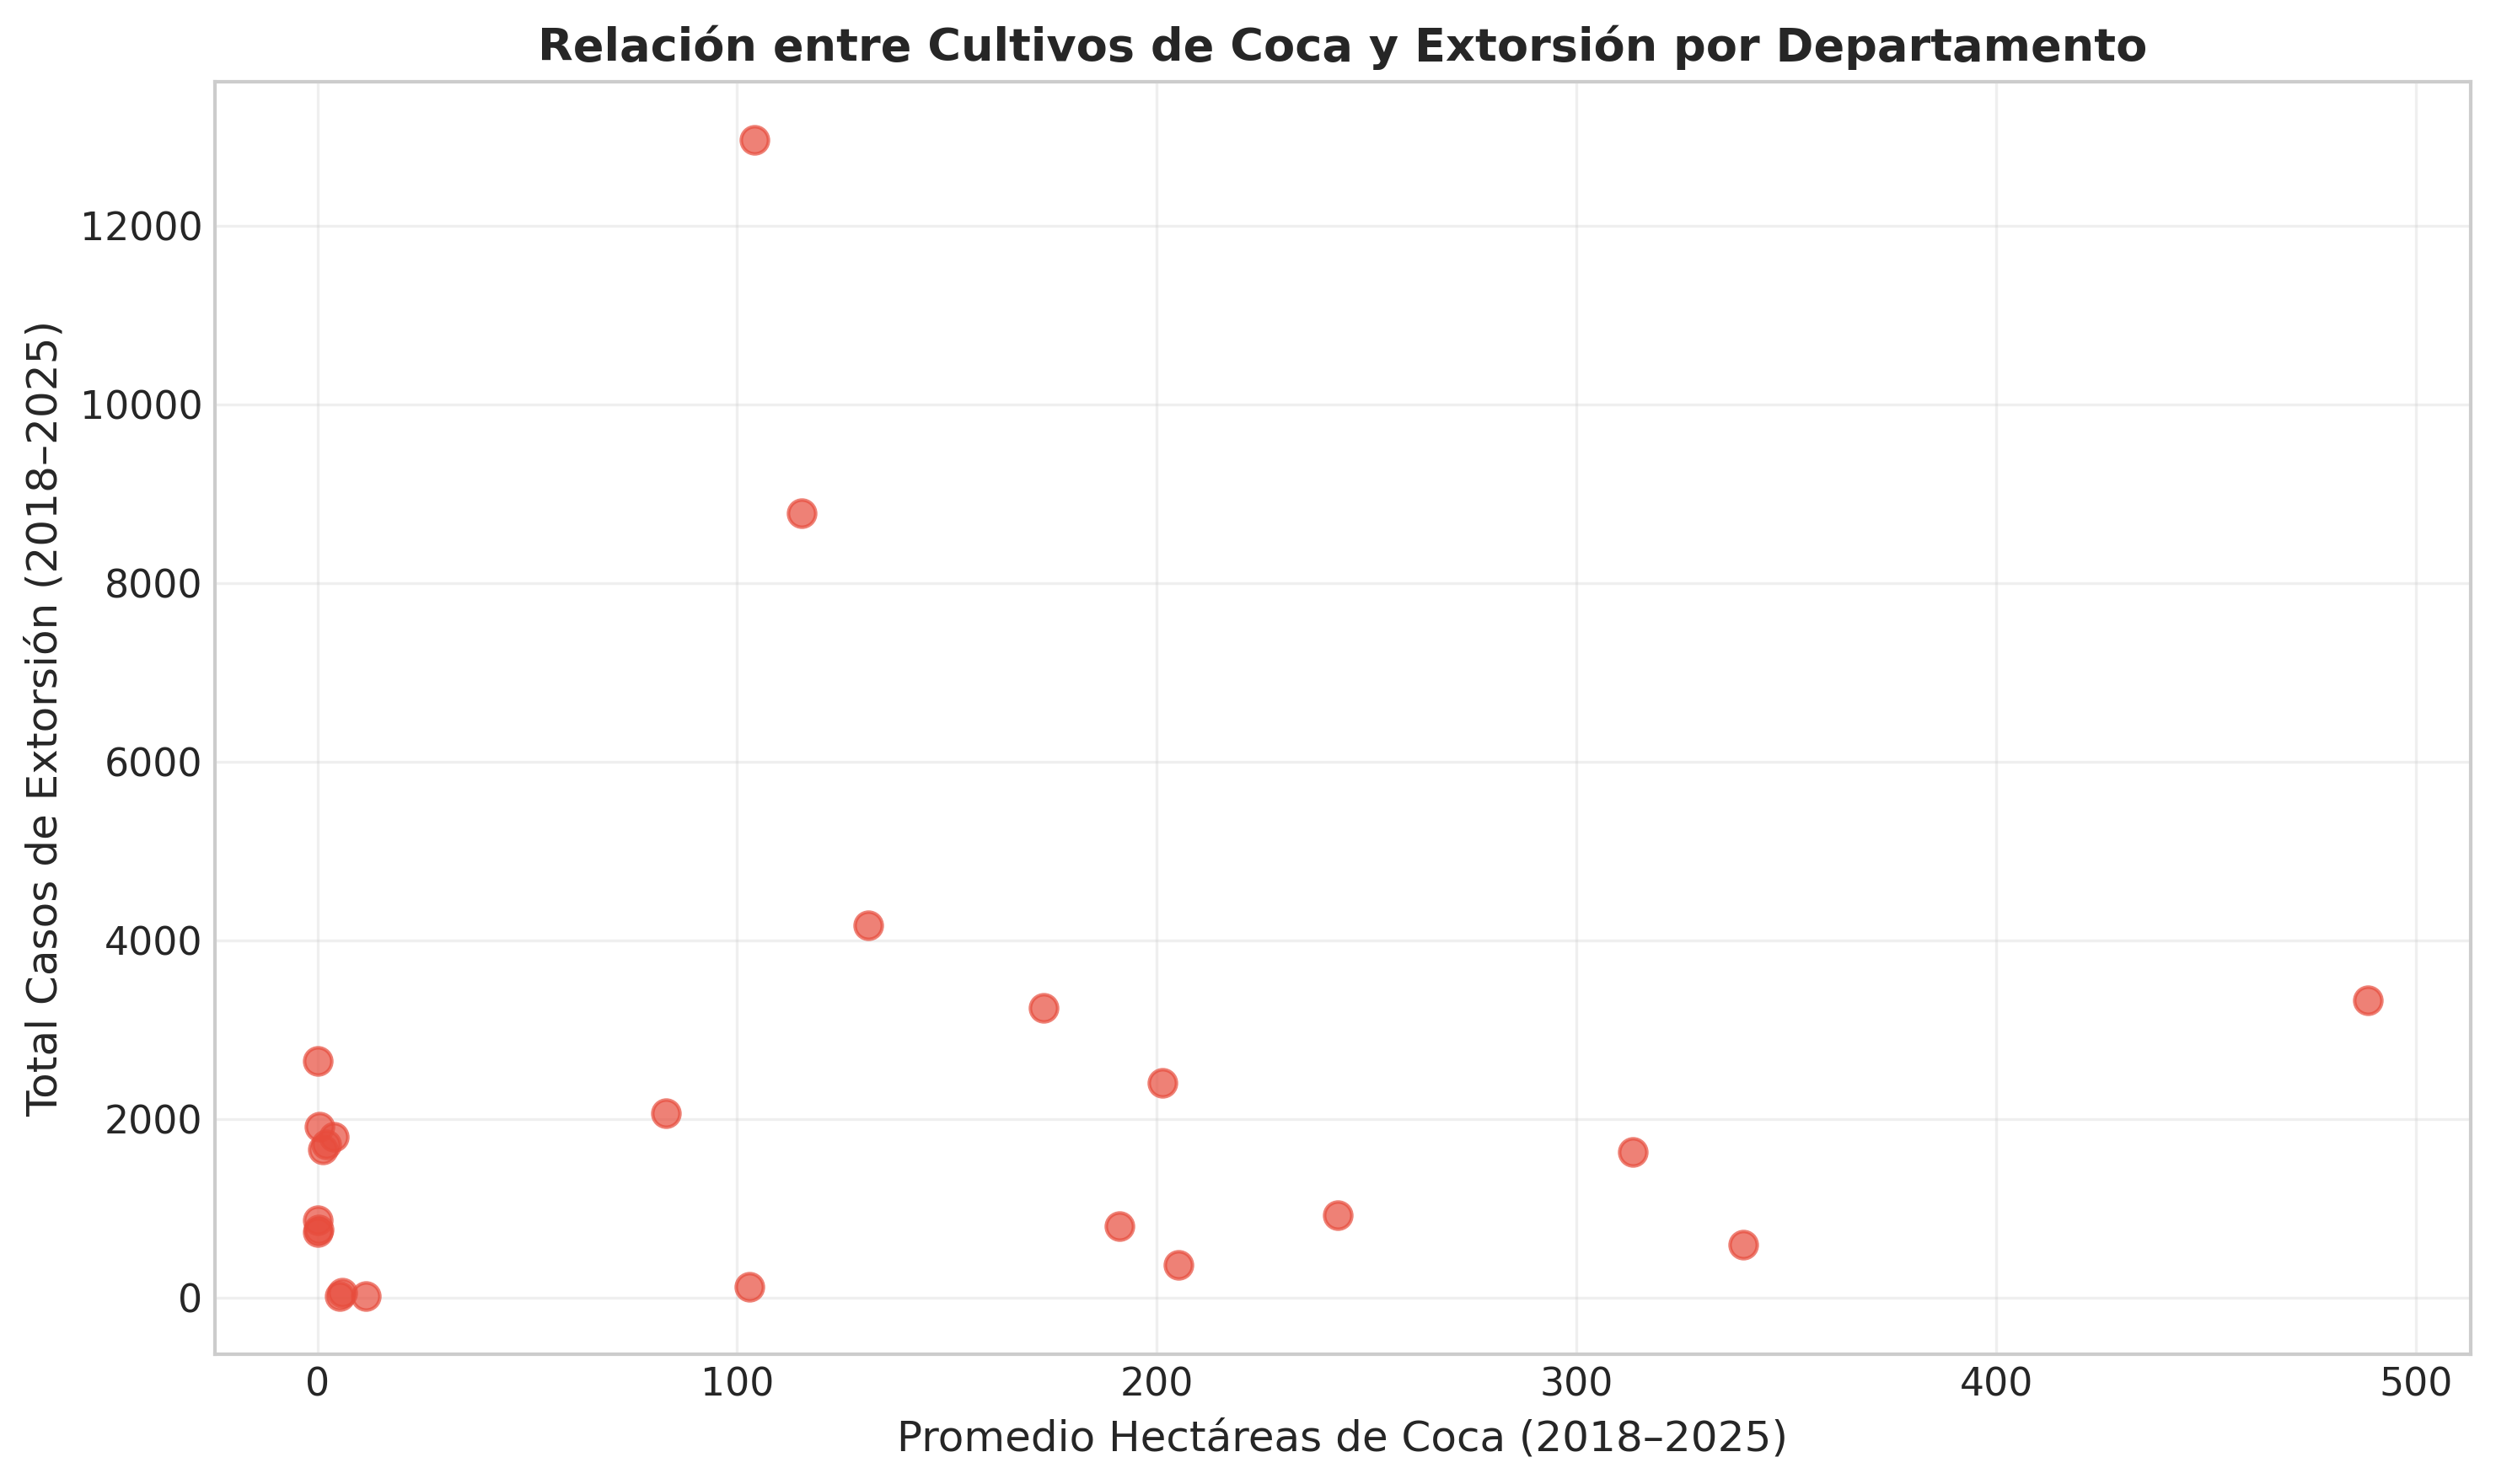

Guardado: 08_coca_vs_extorsion.png


In [10]:
# ── Ilustración 7: Incautaciones ─────────────────────────────────────────────
df_est_anual = (df_estupef[df_estupef['ano'] >= 2018]
    .groupby(['ano', 'tipo_sustancia'])['cantidad'].sum().unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(12, 6))
top_sust = df_est_anual.sum().nlargest(5).index
df_est_anual[top_sust].plot(kind='bar', ax=ax, colormap='tab10')
ax.set_title('Evolución de Incautaciones por Tipo de Sustancia (2018–2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('Cantidad incautada', fontsize=12)
ax.legend(title='Sustancia', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{GRAFICOS_PATH}/07_narcotrafico_evolucion.png', dpi=300, bbox_inches='tight')
plt.show()
print("Guardado: 07_narcotrafico_evolucion.png")

# ── Ilustración 8: Coca vs. Extorsión ────────────────────────────────────────
df_coca_dpto = (df_coca[df_coca['ano'] >= 2018]
    .groupby('cod_dpto')['hectareas'].mean().reset_index()
    .rename(columns={'hectareas': 'hectareas_promedio'}))
df_ext_dpto = (df_extorsion[df_extorsion['ano'] >= 2018]
    .groupby('cod_dpto')['cantidad'].sum().reset_index()
    .rename(columns={'cantidad': 'total_extorsion'}))
df_coca_ext = df_coca_dpto.merge(df_ext_dpto, on='cod_dpto', how='inner')

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_coca_ext['hectareas_promedio'], df_coca_ext['total_extorsion'],
           alpha=0.7, s=60, color='#e74c3c')
ax.set_xlabel('Promedio Hectáreas de Coca (2018–2025)', fontsize=12)
ax.set_ylabel('Total Casos de Extorsión (2018–2025)', fontsize=12)
ax.set_title('Relación entre Cultivos de Coca y Extorsión por Departamento', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{GRAFICOS_PATH}/08_coca_vs_extorsion.png', dpi=300, bbox_inches='tight')
plt.show()
print("Guardado: 08_coca_vs_extorsion.png")


## 8. Relación Extorsión y Población


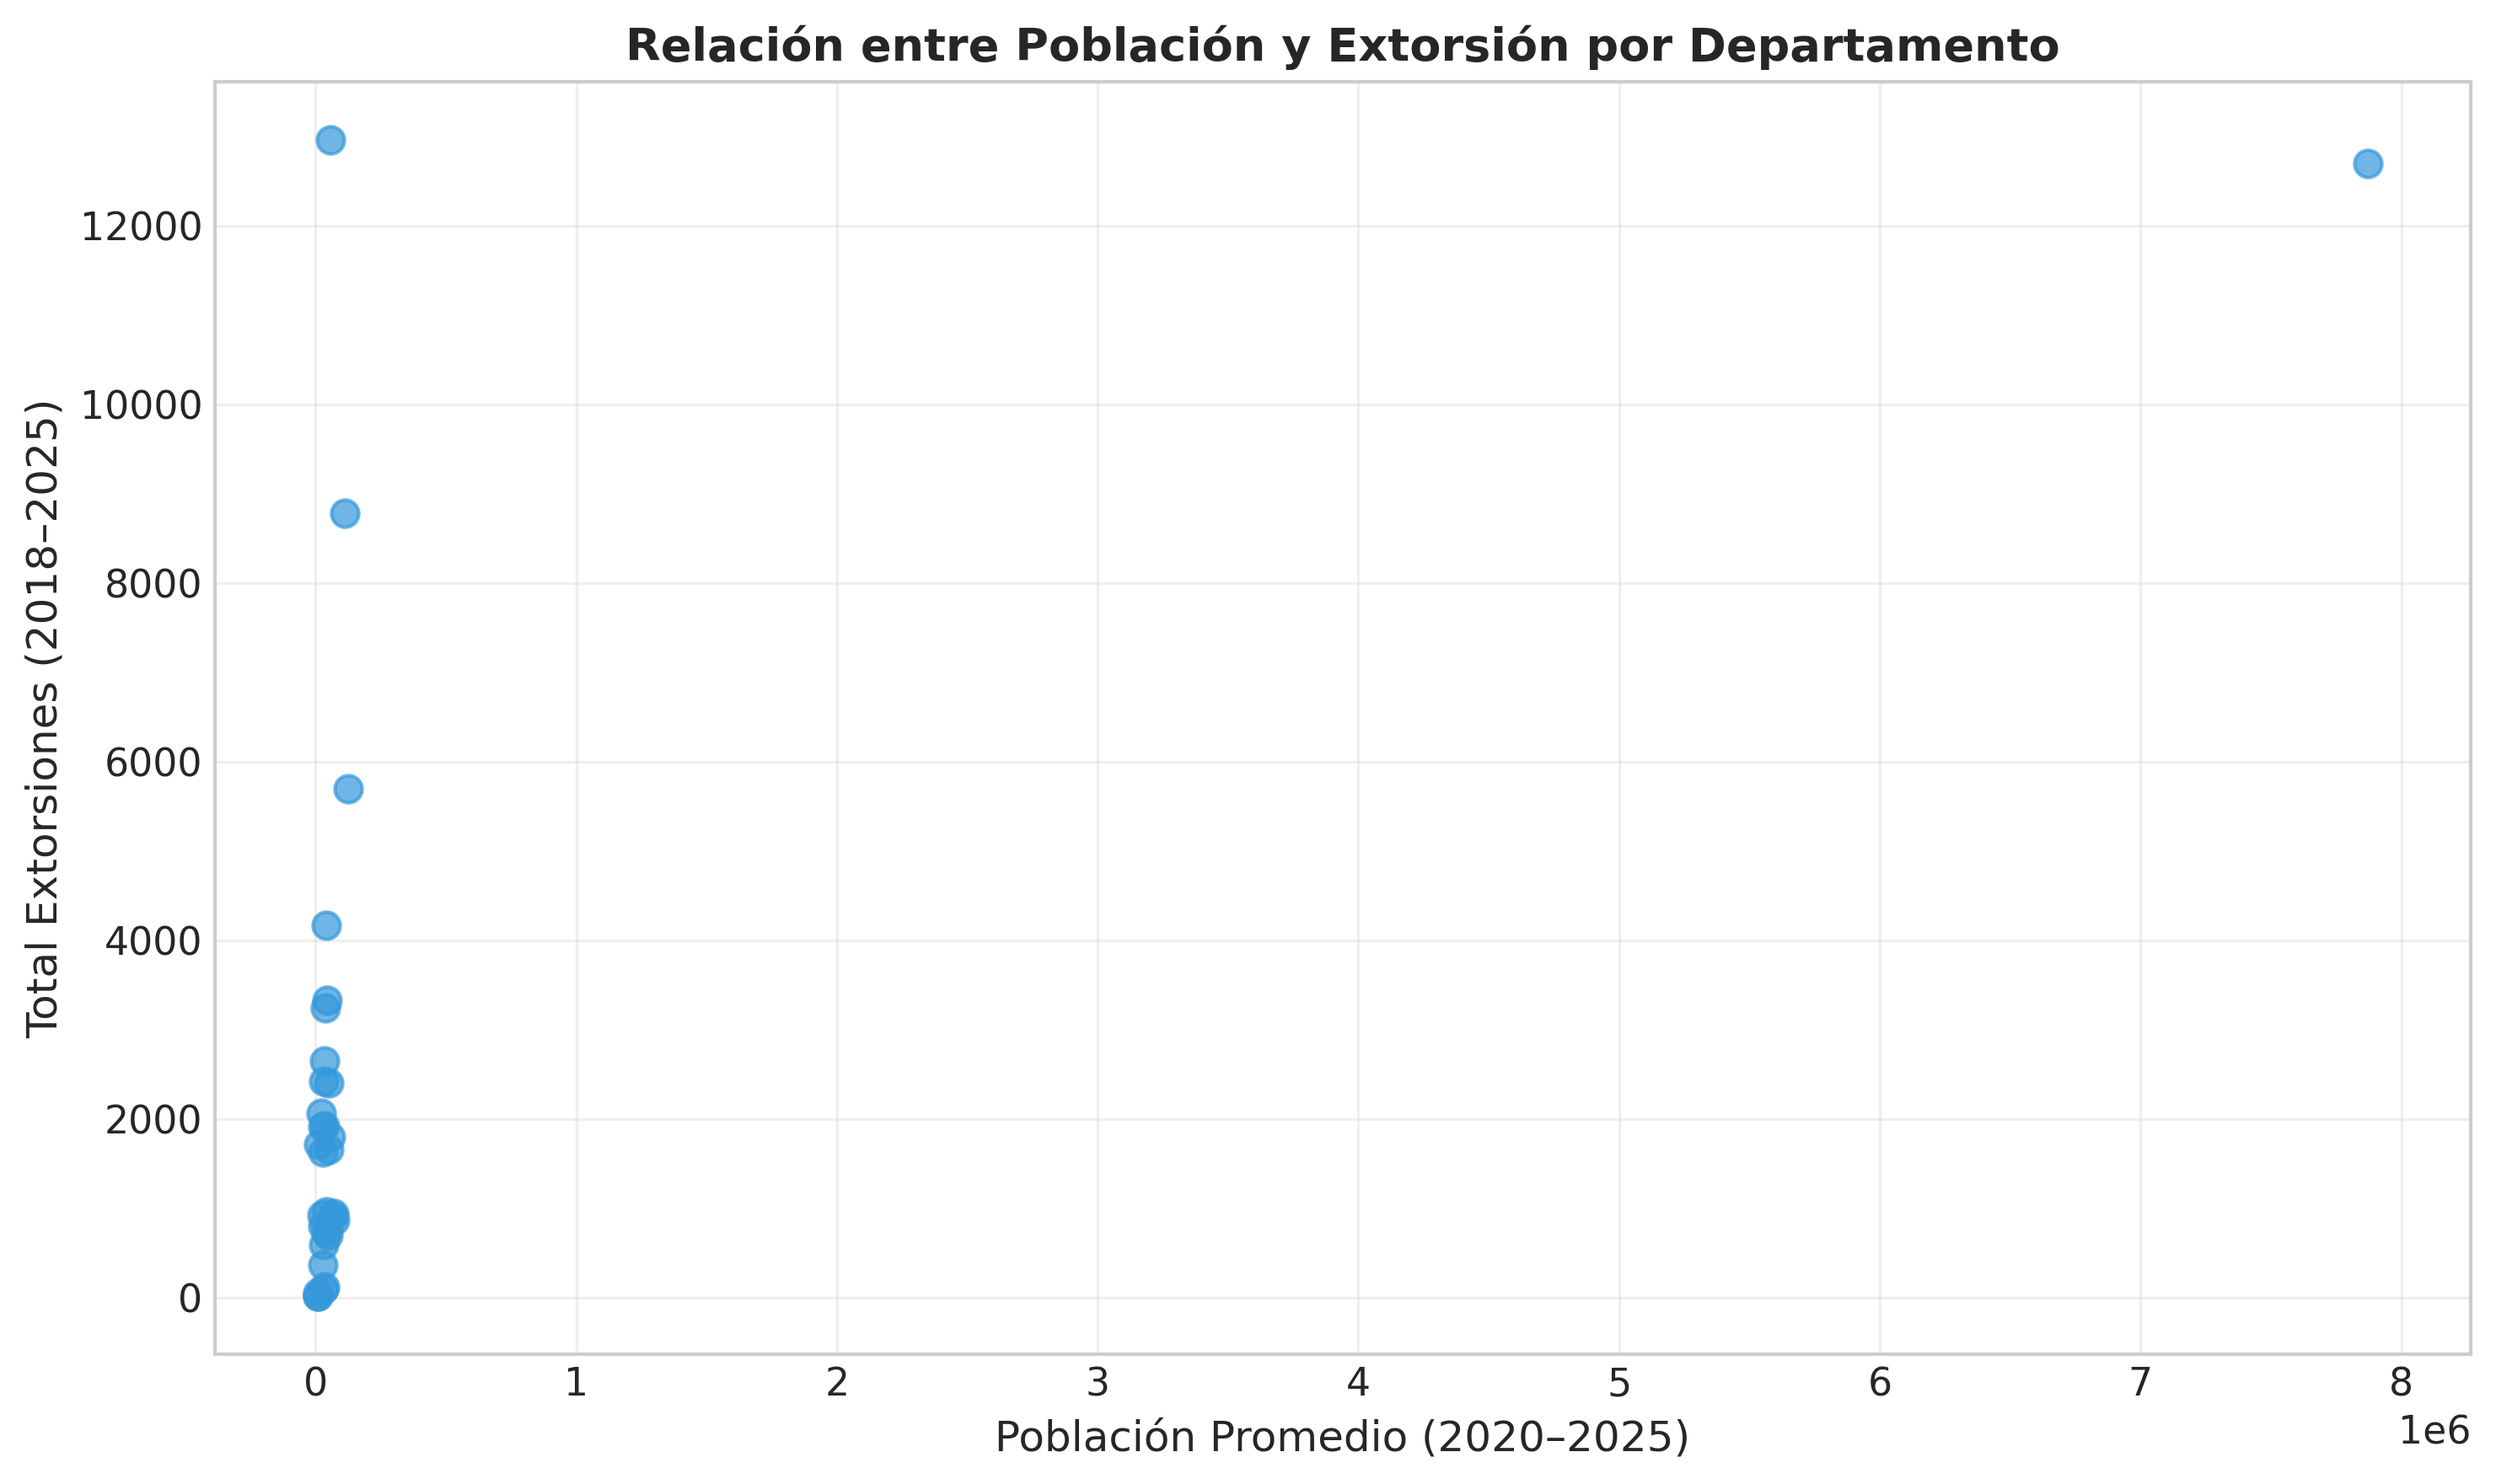

Guardado: 09_poblacion_vs_extorsion.png


In [11]:
df_pob_total = (df_poblacion[df_poblacion['tipo_area'] == 'Total']
    .groupby('cod_dpto')['poblacion'].mean().reset_index()
    .rename(columns={'poblacion': 'pob_promedio'}))
df_ext_dpto2 = (df_extorsion[df_extorsion['ano'] >= 2018]
    .groupby('cod_dpto')['cantidad'].sum().reset_index()
    .rename(columns={'cantidad': 'total_ext'}))
df_pob_ext = df_pob_total.merge(df_ext_dpto2, on='cod_dpto', how='inner')

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_pob_ext['pob_promedio'], df_pob_ext['total_ext'], alpha=0.7, s=60, color='#3498db')
ax.set_xlabel('Población Promedio (2020–2025)', fontsize=12)
ax.set_ylabel('Total Extorsiones (2018–2025)', fontsize=12)
ax.set_title('Relación entre Población y Extorsión por Departamento', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{GRAFICOS_PATH}/09_poblacion_vs_extorsion.png', dpi=300, bbox_inches='tight')
plt.show()
print("Guardado: 09_poblacion_vs_extorsion.png")


## 9. Cobertura Telecomunicaciones


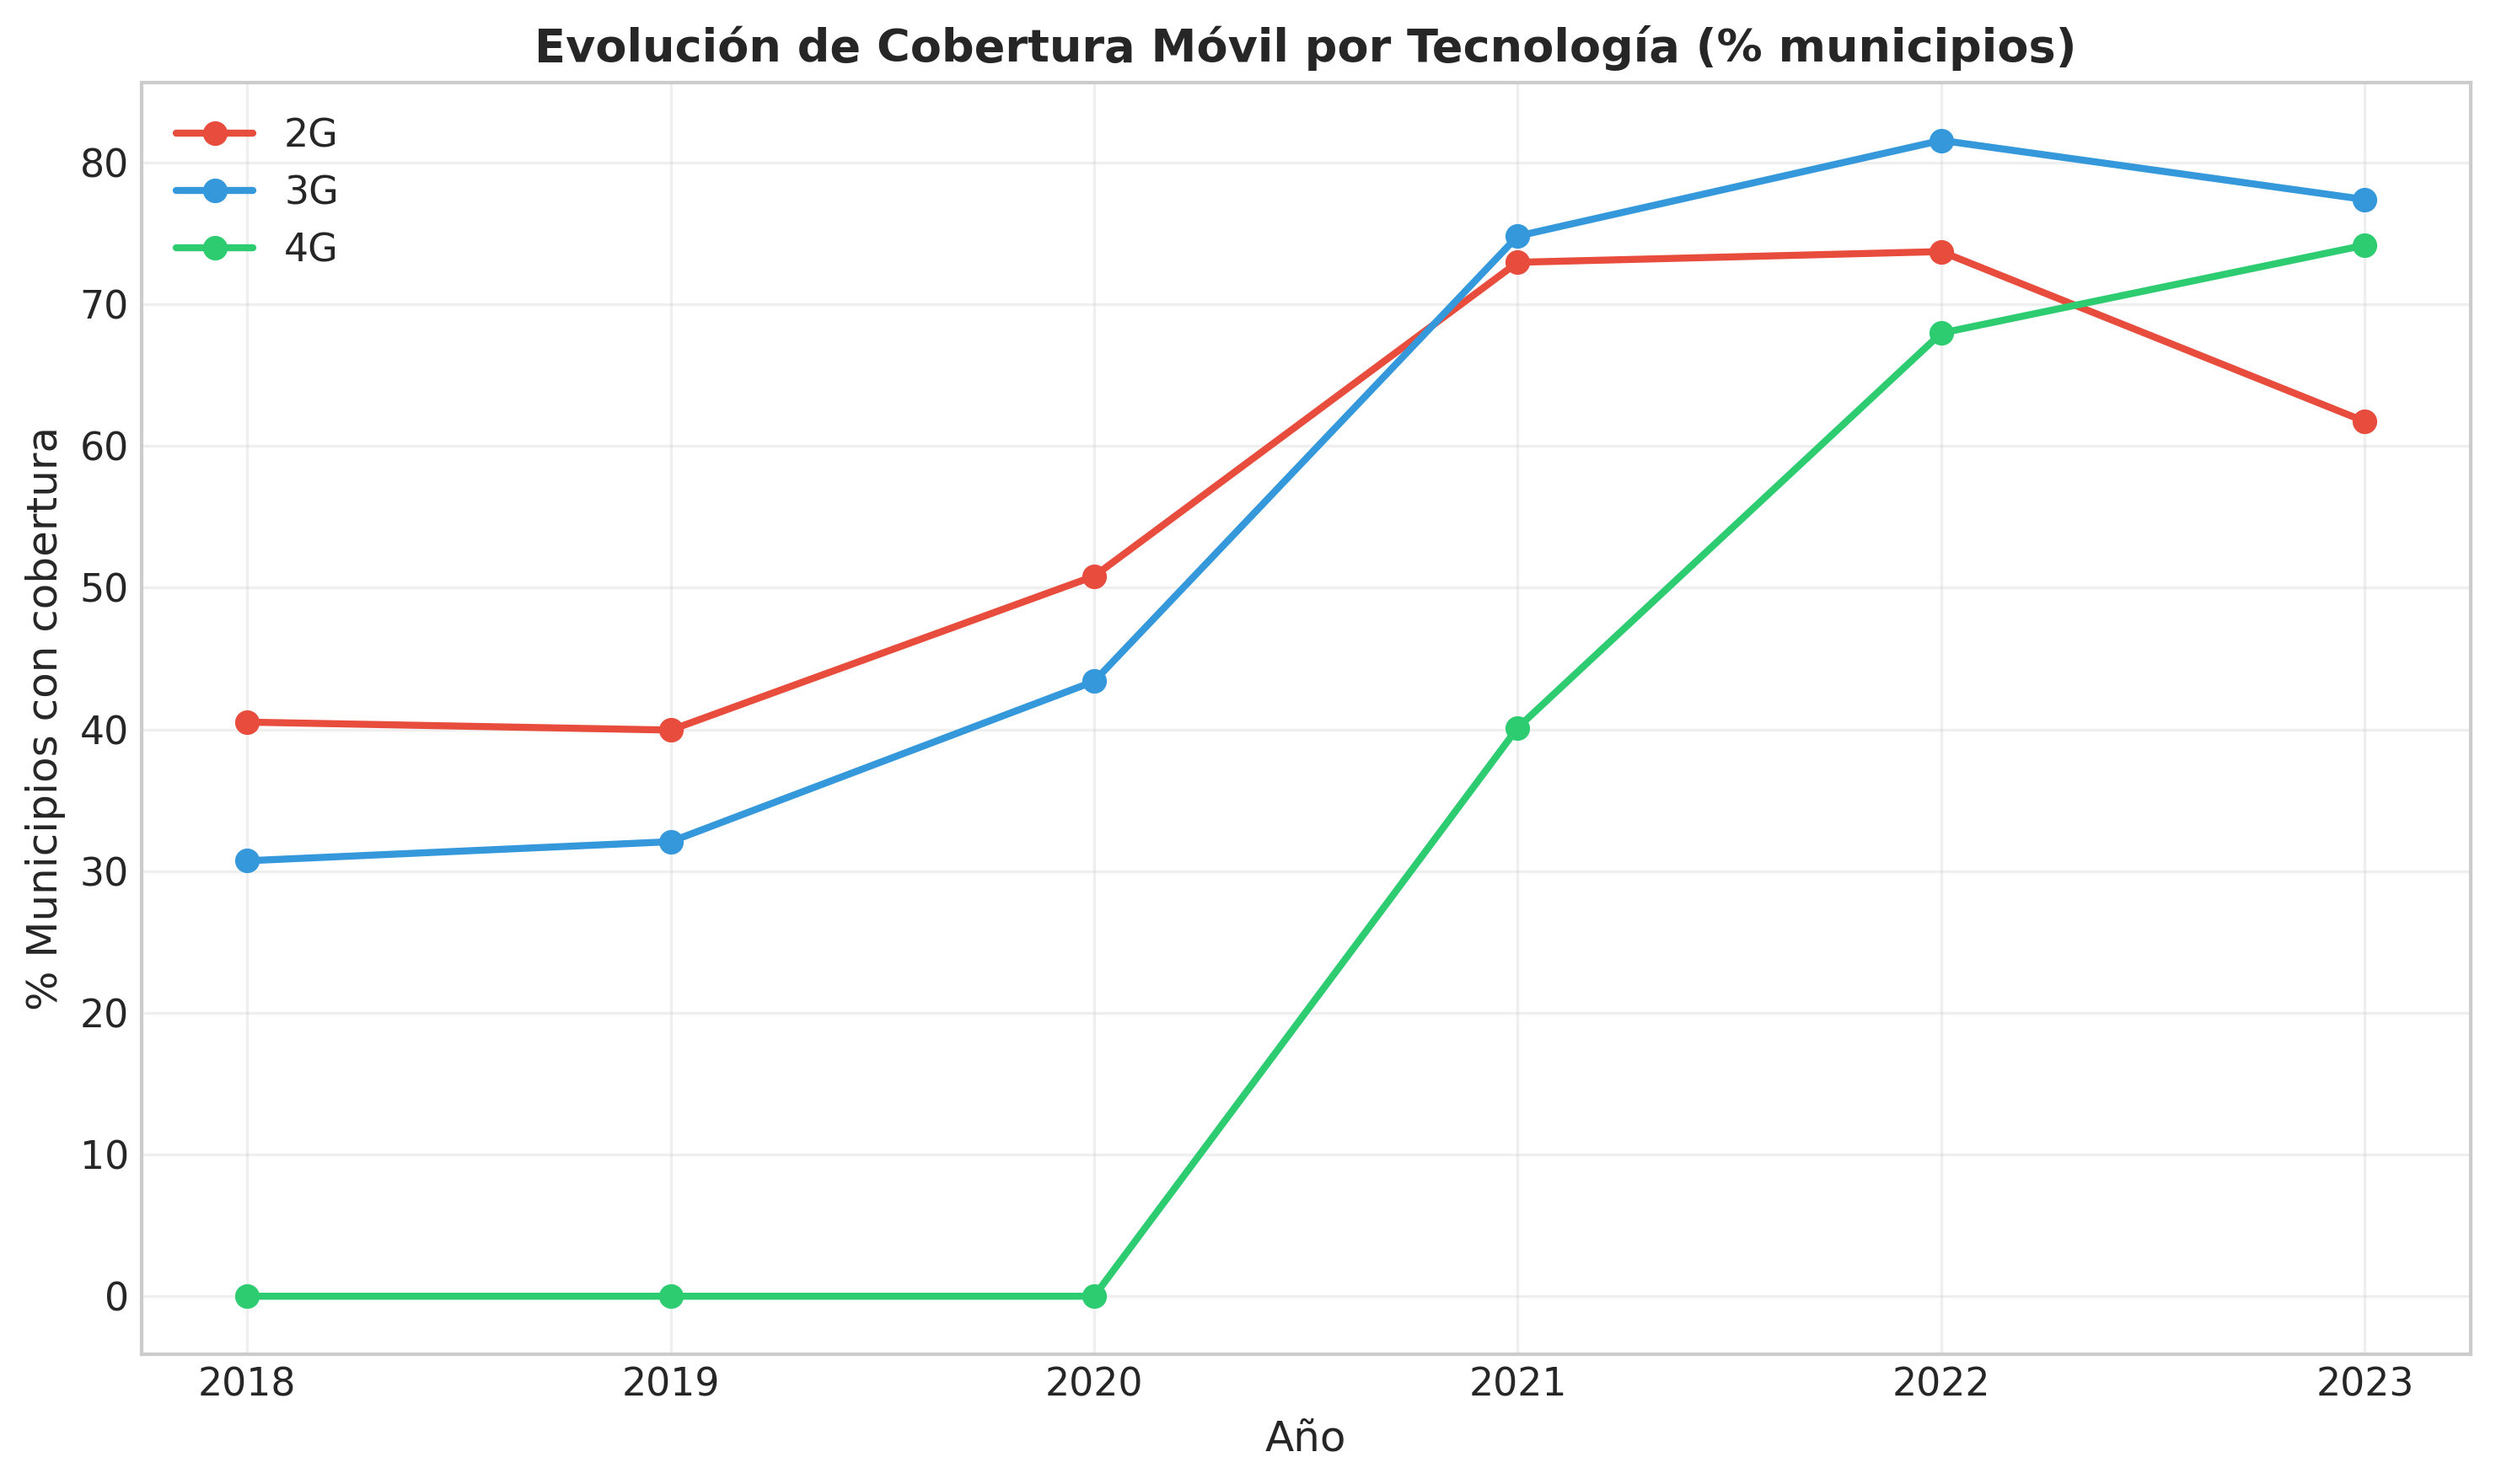

Guardado: 10_evolucion_cobertura_telecom.png


In [12]:
df_cob_anual = (df_cobertura[df_cobertura['ano'] >= 2018]
    .groupby('ano')[['cobertura_2g', 'cobertura_3g', 'cobertura_4g']].mean()
    .multiply(100))  # a porcentaje

fig, ax = plt.subplots(figsize=(10, 6))
for col, label, color in zip(['cobertura_2g', 'cobertura_3g', 'cobertura_4g'],
                               ['2G', '3G', '4G'],
                               ['#e74c3c', '#3498db', '#2ecc71']):
    if col in df_cob_anual.columns:
        ax.plot(df_cob_anual.index, df_cob_anual[col], label=label, linewidth=2, marker='o', color=color)
ax.set_title('Evolución de Cobertura Móvil por Tecnología (% municipios)', fontsize=13, fontweight='bold')
ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('% Municipios con cobertura', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig(f'{GRAFICOS_PATH}/10_evolucion_cobertura_telecom.png', dpi=300, bbox_inches='tight')
plt.show()
print("Guardado: 10_evolucion_cobertura_telecom.png")


## 10. Terrorismo


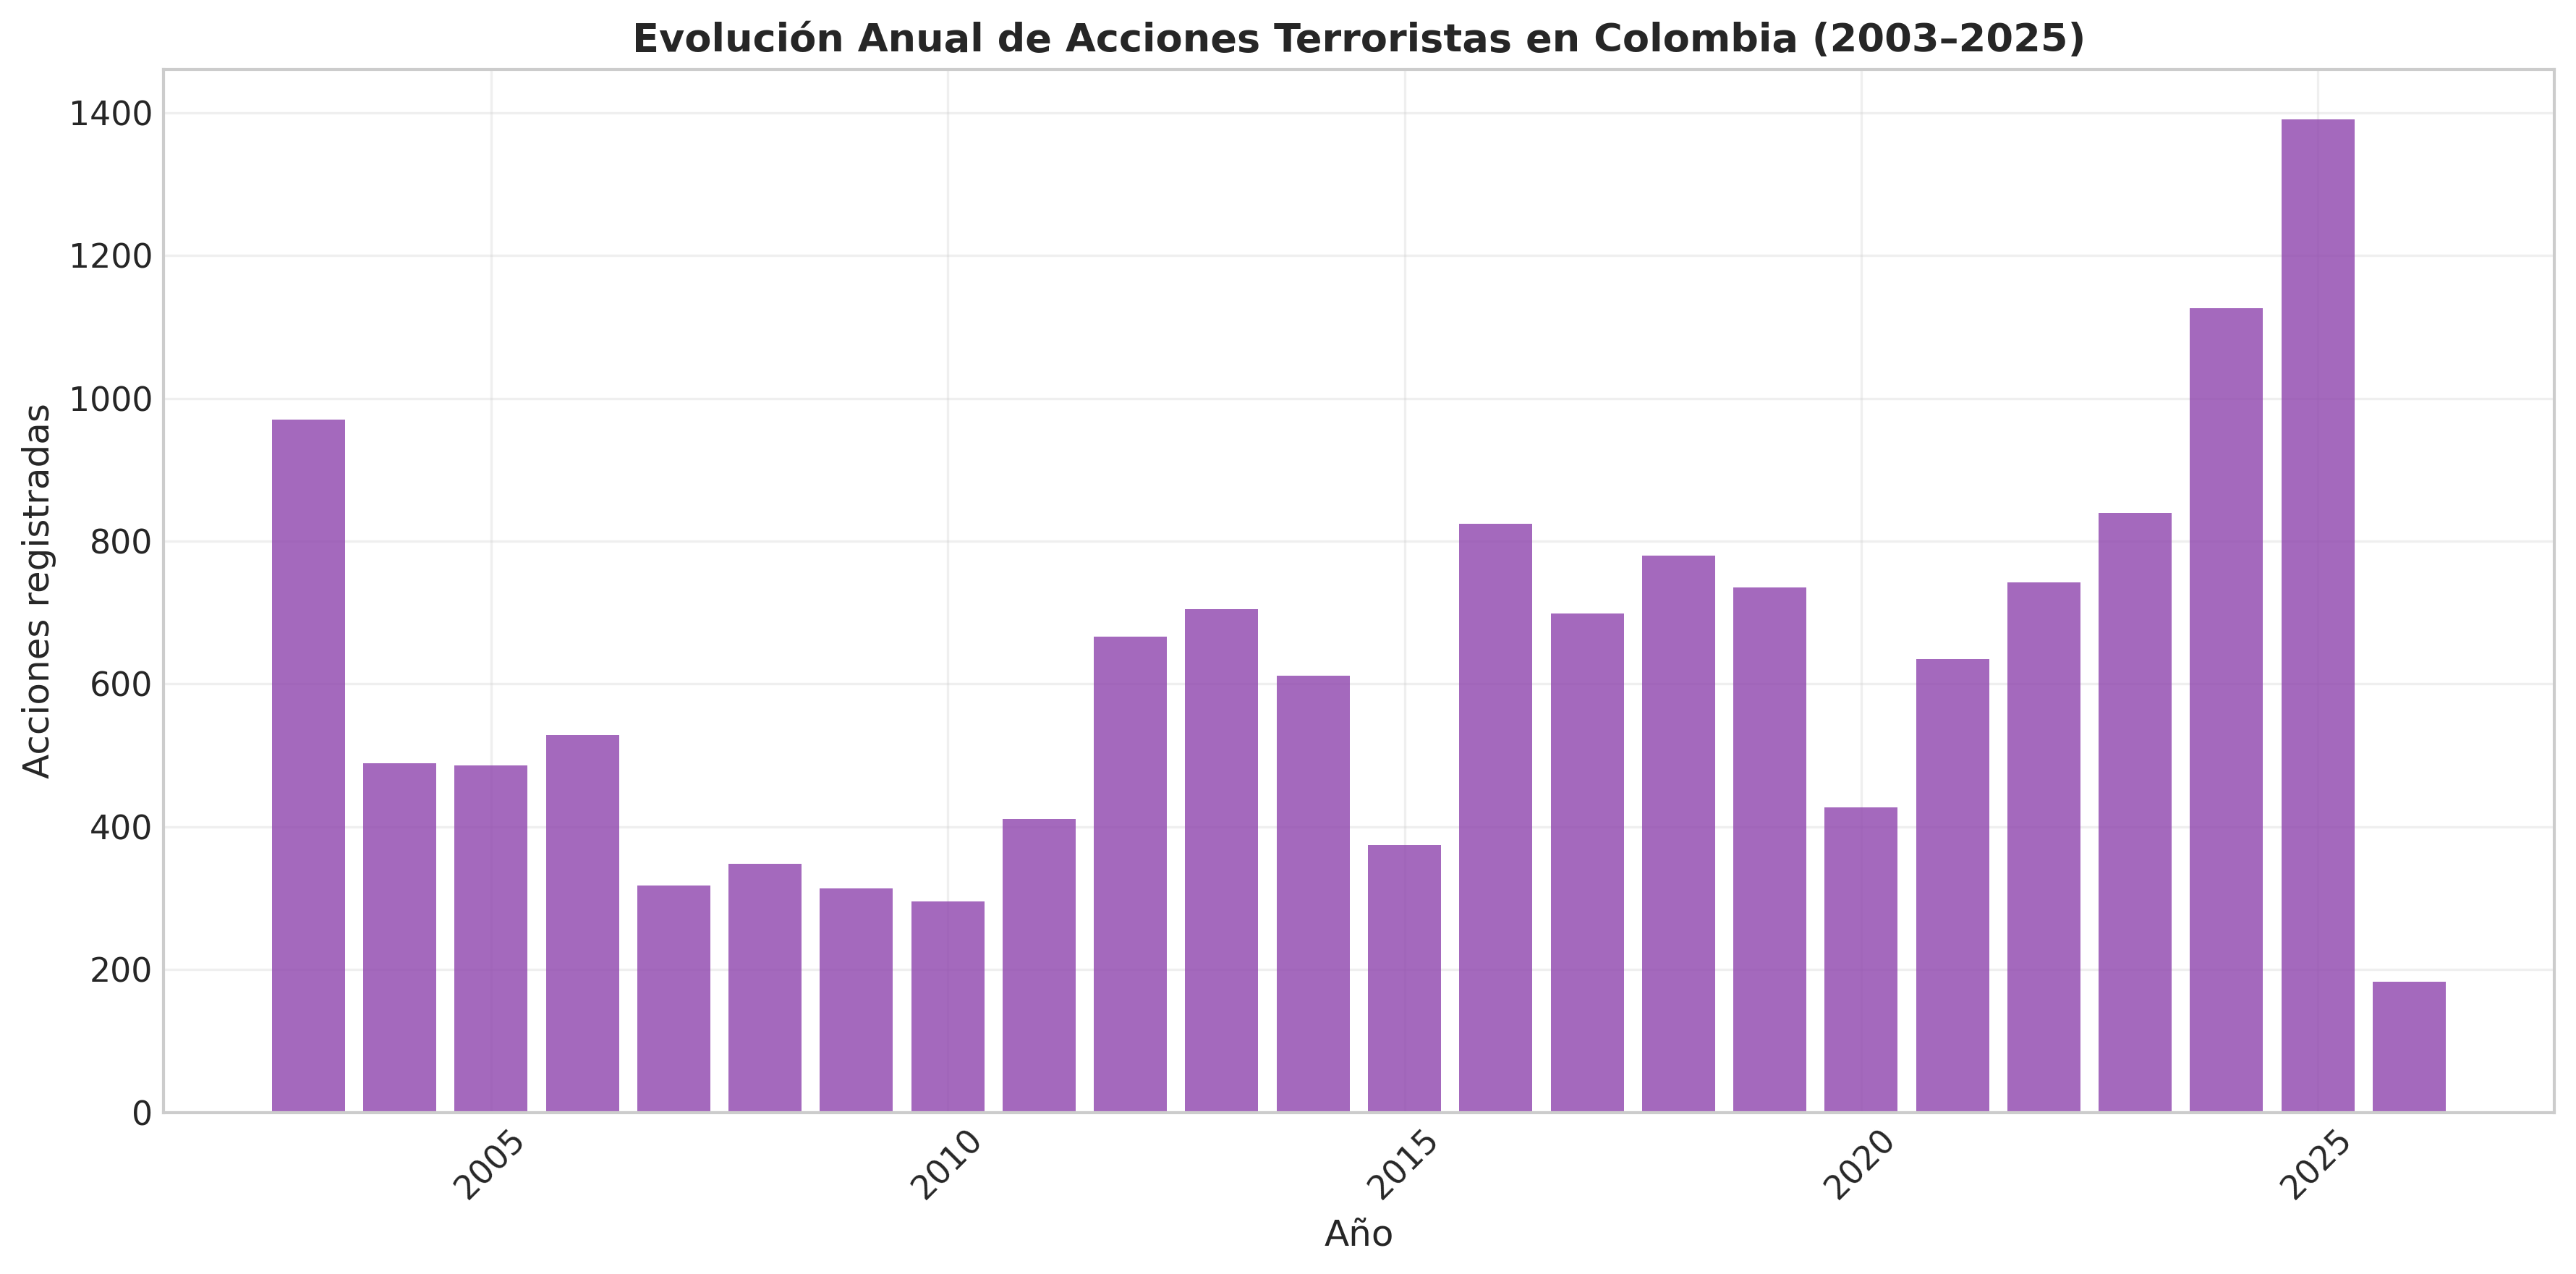

Guardado: 14_terrorismo_evolucion.png


In [13]:
df_ter_anual = (df_terrorismo[df_terrorismo['ano'] >= 2003]
    .groupby('ano')['cantidad'].sum().reset_index())

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(df_ter_anual['ano'], df_ter_anual['cantidad'], color='#8e44ad', alpha=0.8)
ax.set_title('Evolución Anual de Acciones Terroristas en Colombia (2003–2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('Acciones registradas', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{GRAFICOS_PATH}/14_terrorismo_evolucion.png', dpi=300, bbox_inches='tight')
plt.show()
print("Guardado: 14_terrorismo_evolucion.png")


## 11. Matrices de Correlación (Nivel Nacional y Departamental)


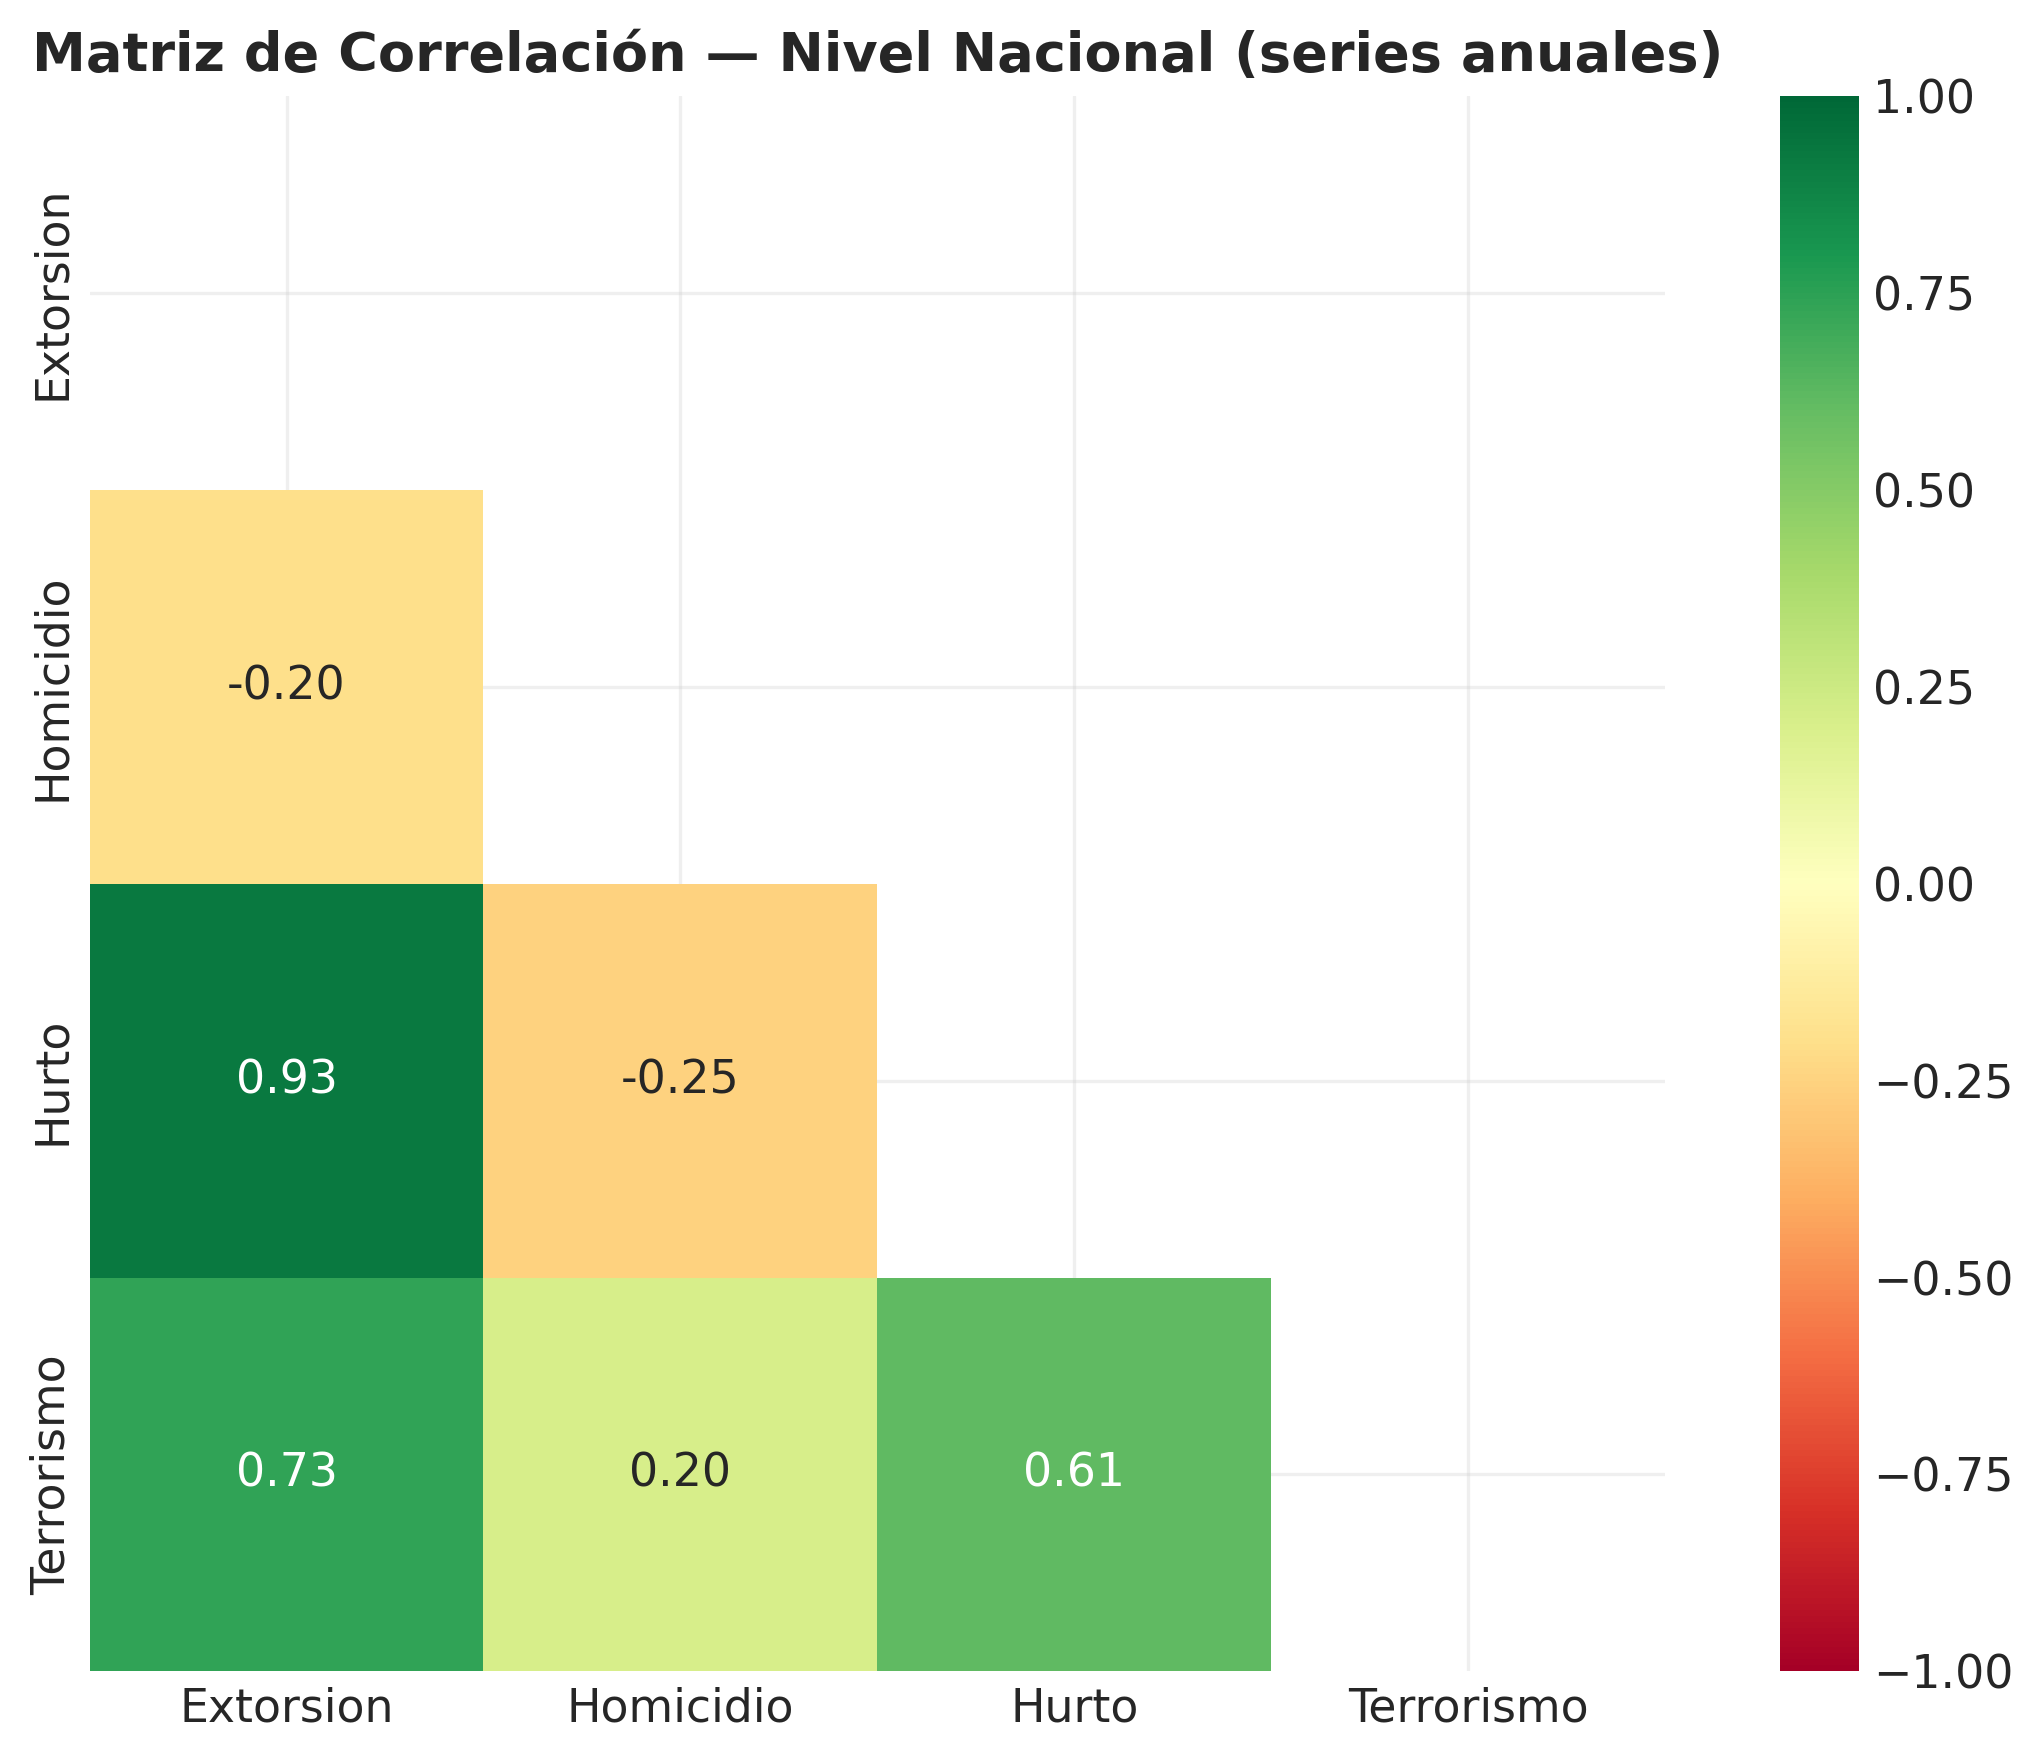

Guardado: 11_matriz_correlacion_nacional.png


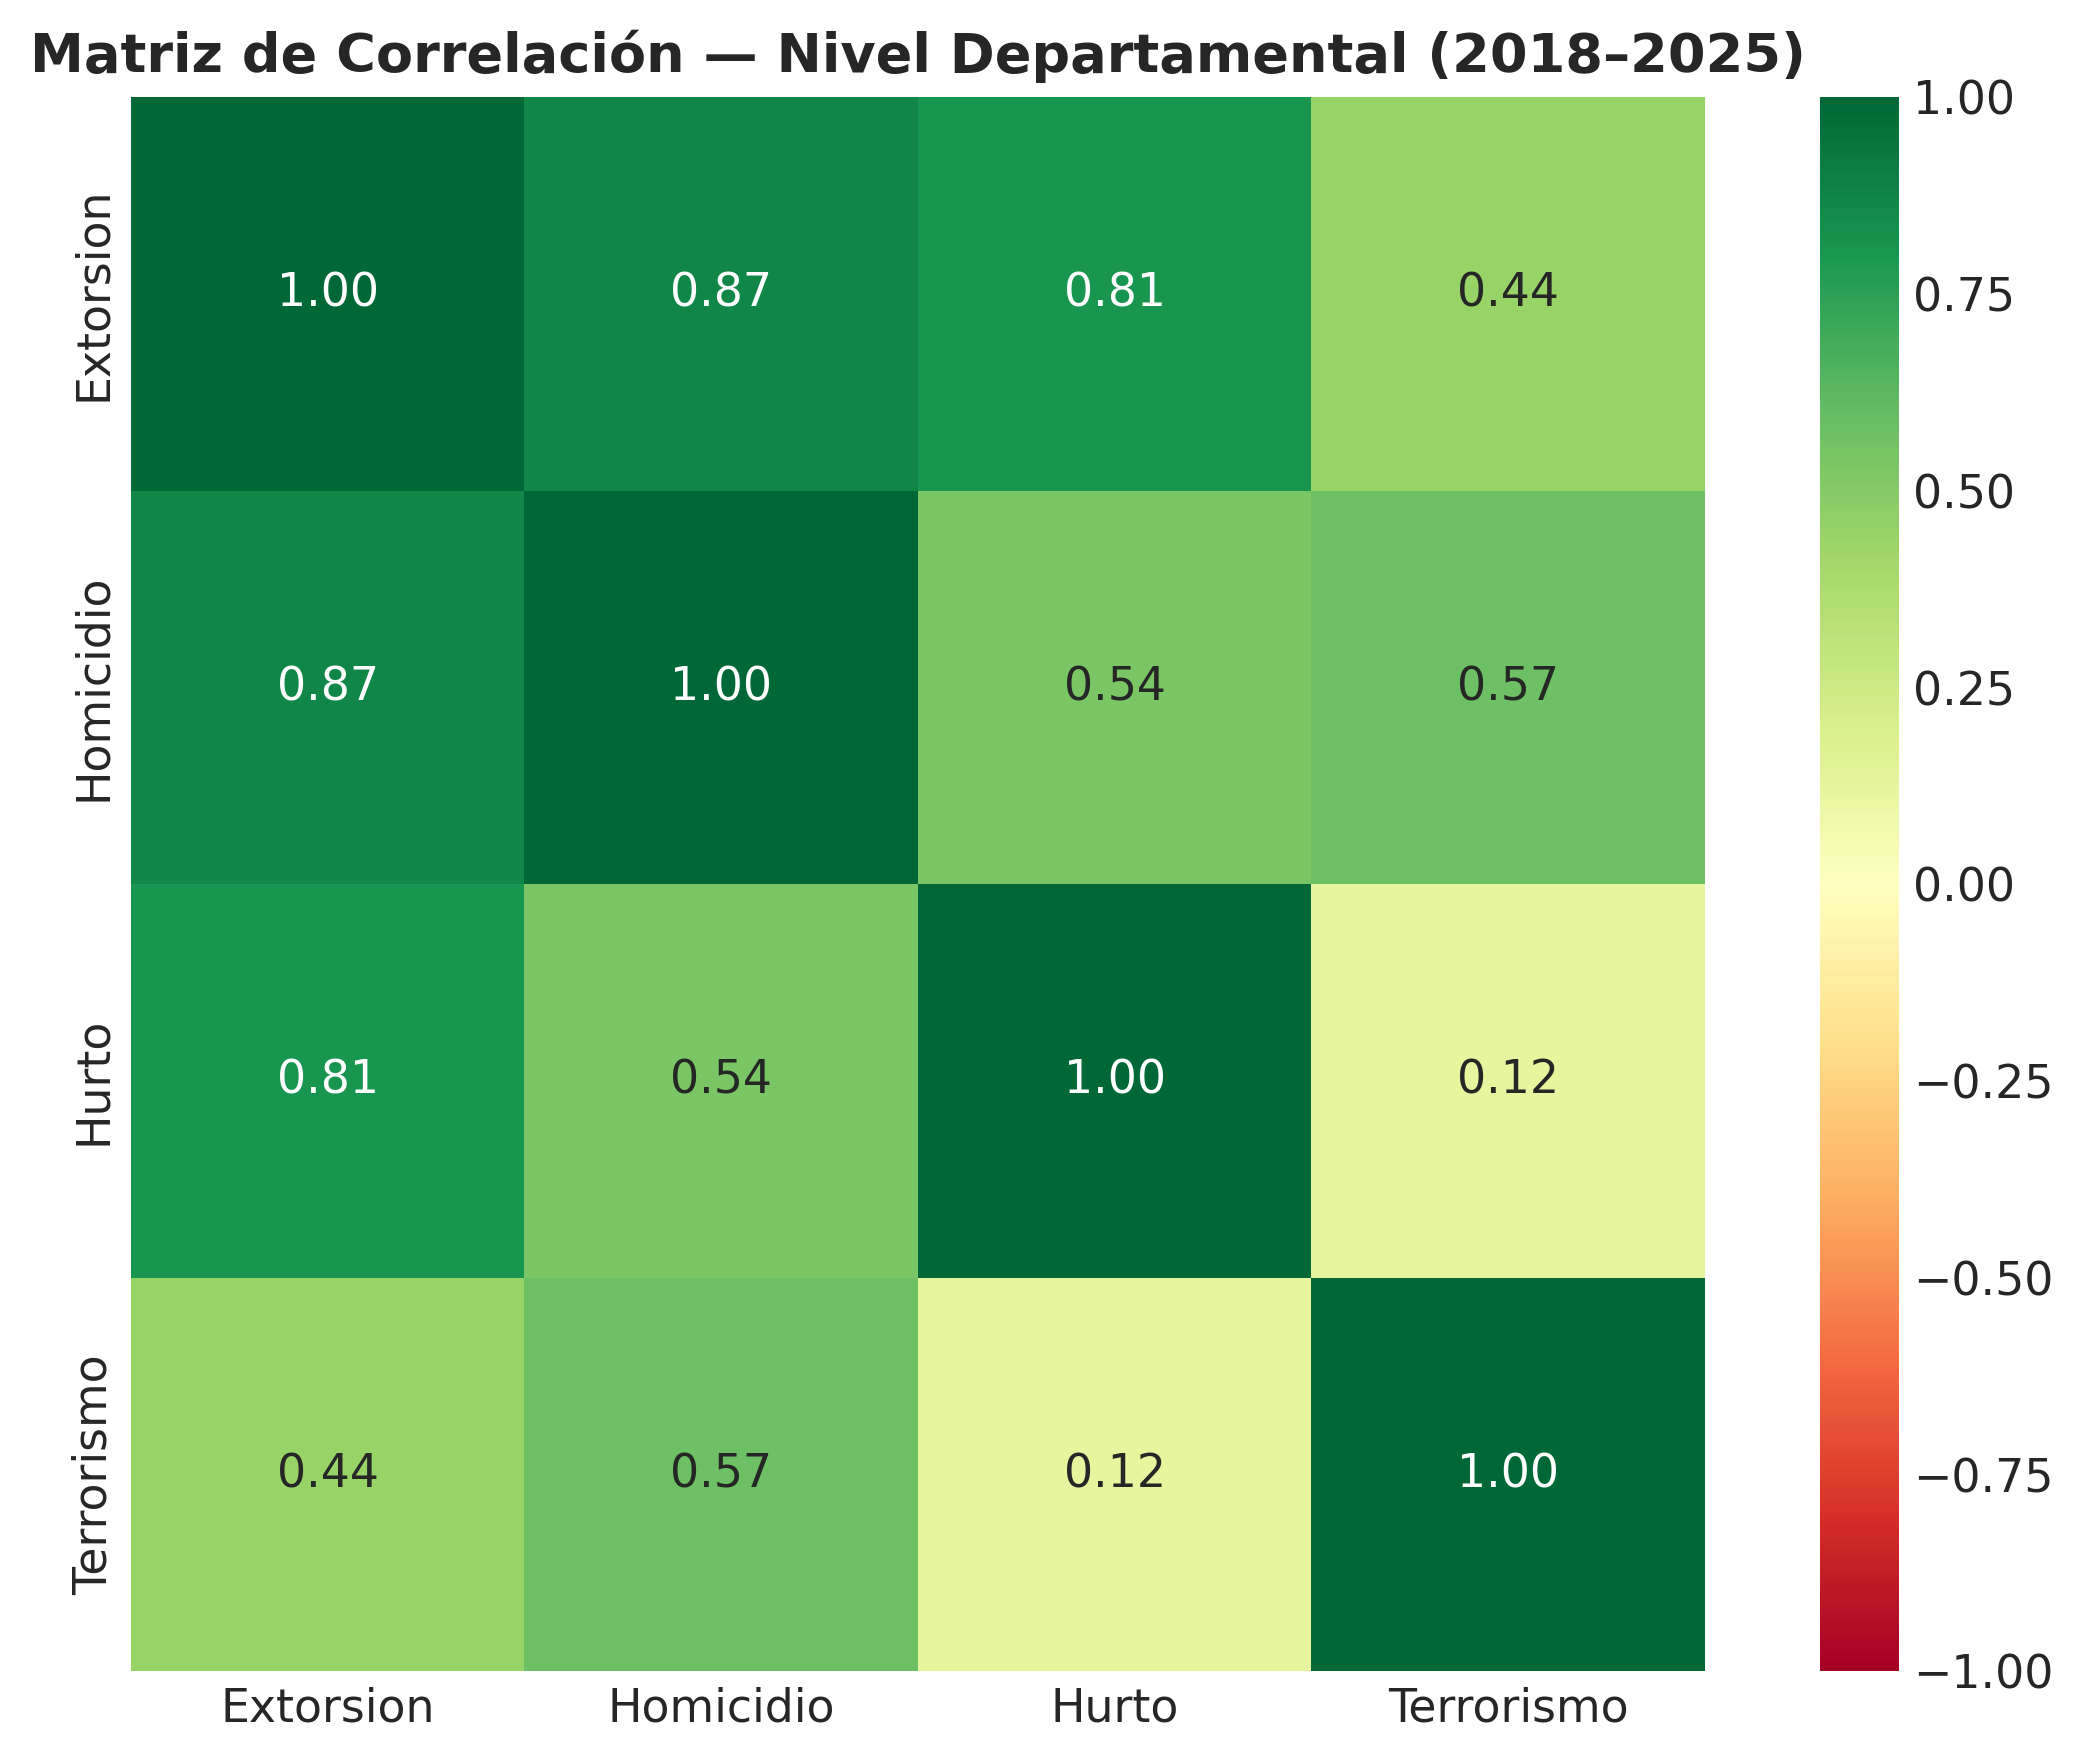

Guardado: 12_matriz_correlacion_departamental.png


In [14]:
# ── Correlaciones nacionales anuales ─────────────────────────────────────────
def pivot_anual(df, col='cantidad', nombre='delito'):
    return (df[df['ano'] >= 2003].groupby('ano')[col].sum().rename(nombre))

df_corr_nac = pd.concat([
    pivot_anual(df_extorsion,  nombre='Extorsion'),
    pivot_anual(df_homicidio,  nombre='Homicidio'),
    pivot_anual(df_hurto,      nombre='Hurto'),
    pivot_anual(df_terrorismo, nombre='Terrorismo'),
], axis=1).dropna()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(df_corr_nac.corr(), dtype=bool))
sns.heatmap(df_corr_nac.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, ax=ax, mask=mask, square=True)
ax.set_title('Matriz de Correlación — Nivel Nacional (series anuales)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{GRAFICOS_PATH}/11_matriz_correlacion_nacional.png', dpi=300, bbox_inches='tight')
plt.show()
print("Guardado: 11_matriz_correlacion_nacional.png")

# ── Correlaciones departamentales ─────────────────────────────────────────────
def pivot_dpto(df, col='cantidad', nombre='delito'):
    return (df[df['ano'] >= 2018].groupby('cod_dpto')[col].sum().rename(nombre))

df_corr_dpto = pd.concat([
    pivot_dpto(df_extorsion,  nombre='Extorsion'),
    pivot_dpto(df_homicidio,  nombre='Homicidio'),
    pivot_dpto(df_hurto,      nombre='Hurto'),
    pivot_dpto(df_terrorismo, nombre='Terrorismo'),
], axis=1).dropna()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df_corr_dpto.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Matriz de Correlación — Nivel Departamental (2018–2025)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{GRAFICOS_PATH}/12_matriz_correlacion_departamental.png', dpi=300, bbox_inches='tight')
plt.show()
print("Guardado: 12_matriz_correlacion_departamental.png")


## 12. Ilustraciones de Selección de Variables (Sección 8)

Las siguientes 3 ilustraciones (18–20) sustentan directamente la sección 8 del TFM.
Se generan sobre el dataset de modelado Gold (`consolidado_modelado.csv`).

**Decisión metodológica de variables**:
- `cod_mun` excluido: >1.046 categorías generarían >1.000 dummies (maldición de la dimensionalidad)
- `cod_dpto` incluido: solo 33 categorías, captura efectos regionales manejables
- Variables lag excluidas: causaron VIF > 100 (multicolinealidad severa)
- Variables predictoras finales: `poblacion_total`, `total_hurto`, `total_homicidio`,
  `incautaciones_total`, `cantidad_total_kg`, `total_terrorismo`


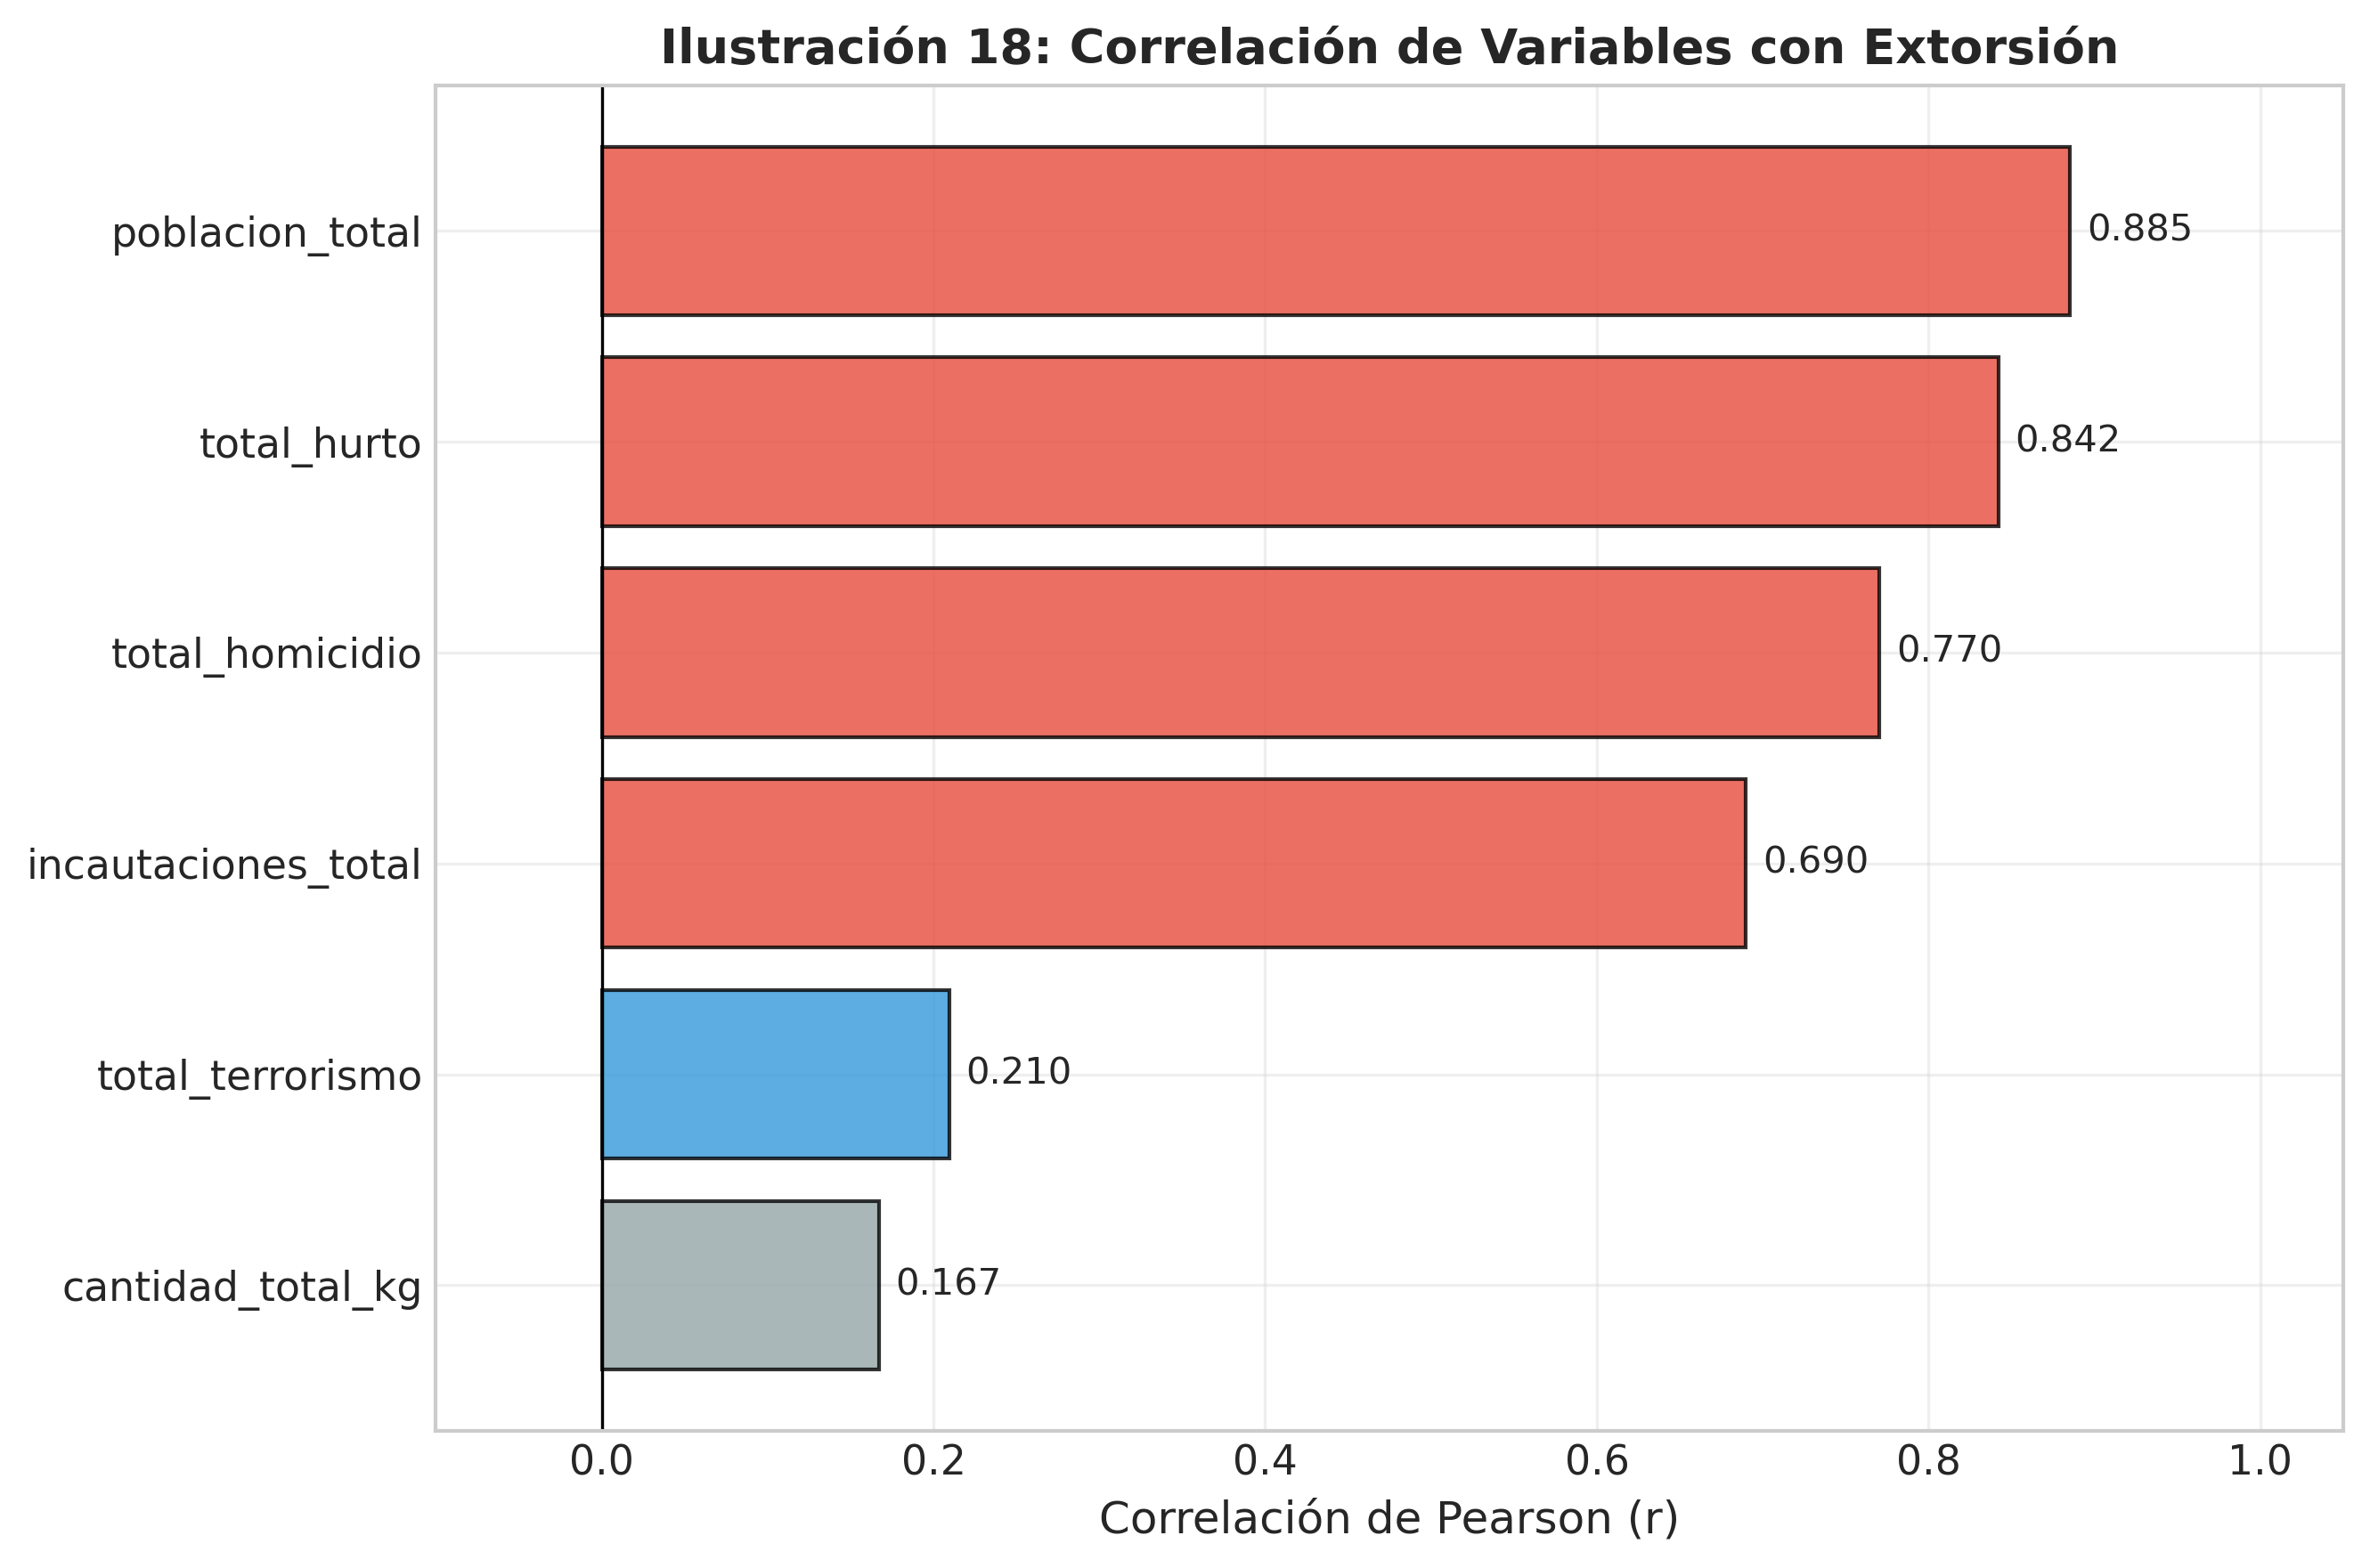

Guardado: ILUSTRACION_18_correlacion_con_extorsion.png


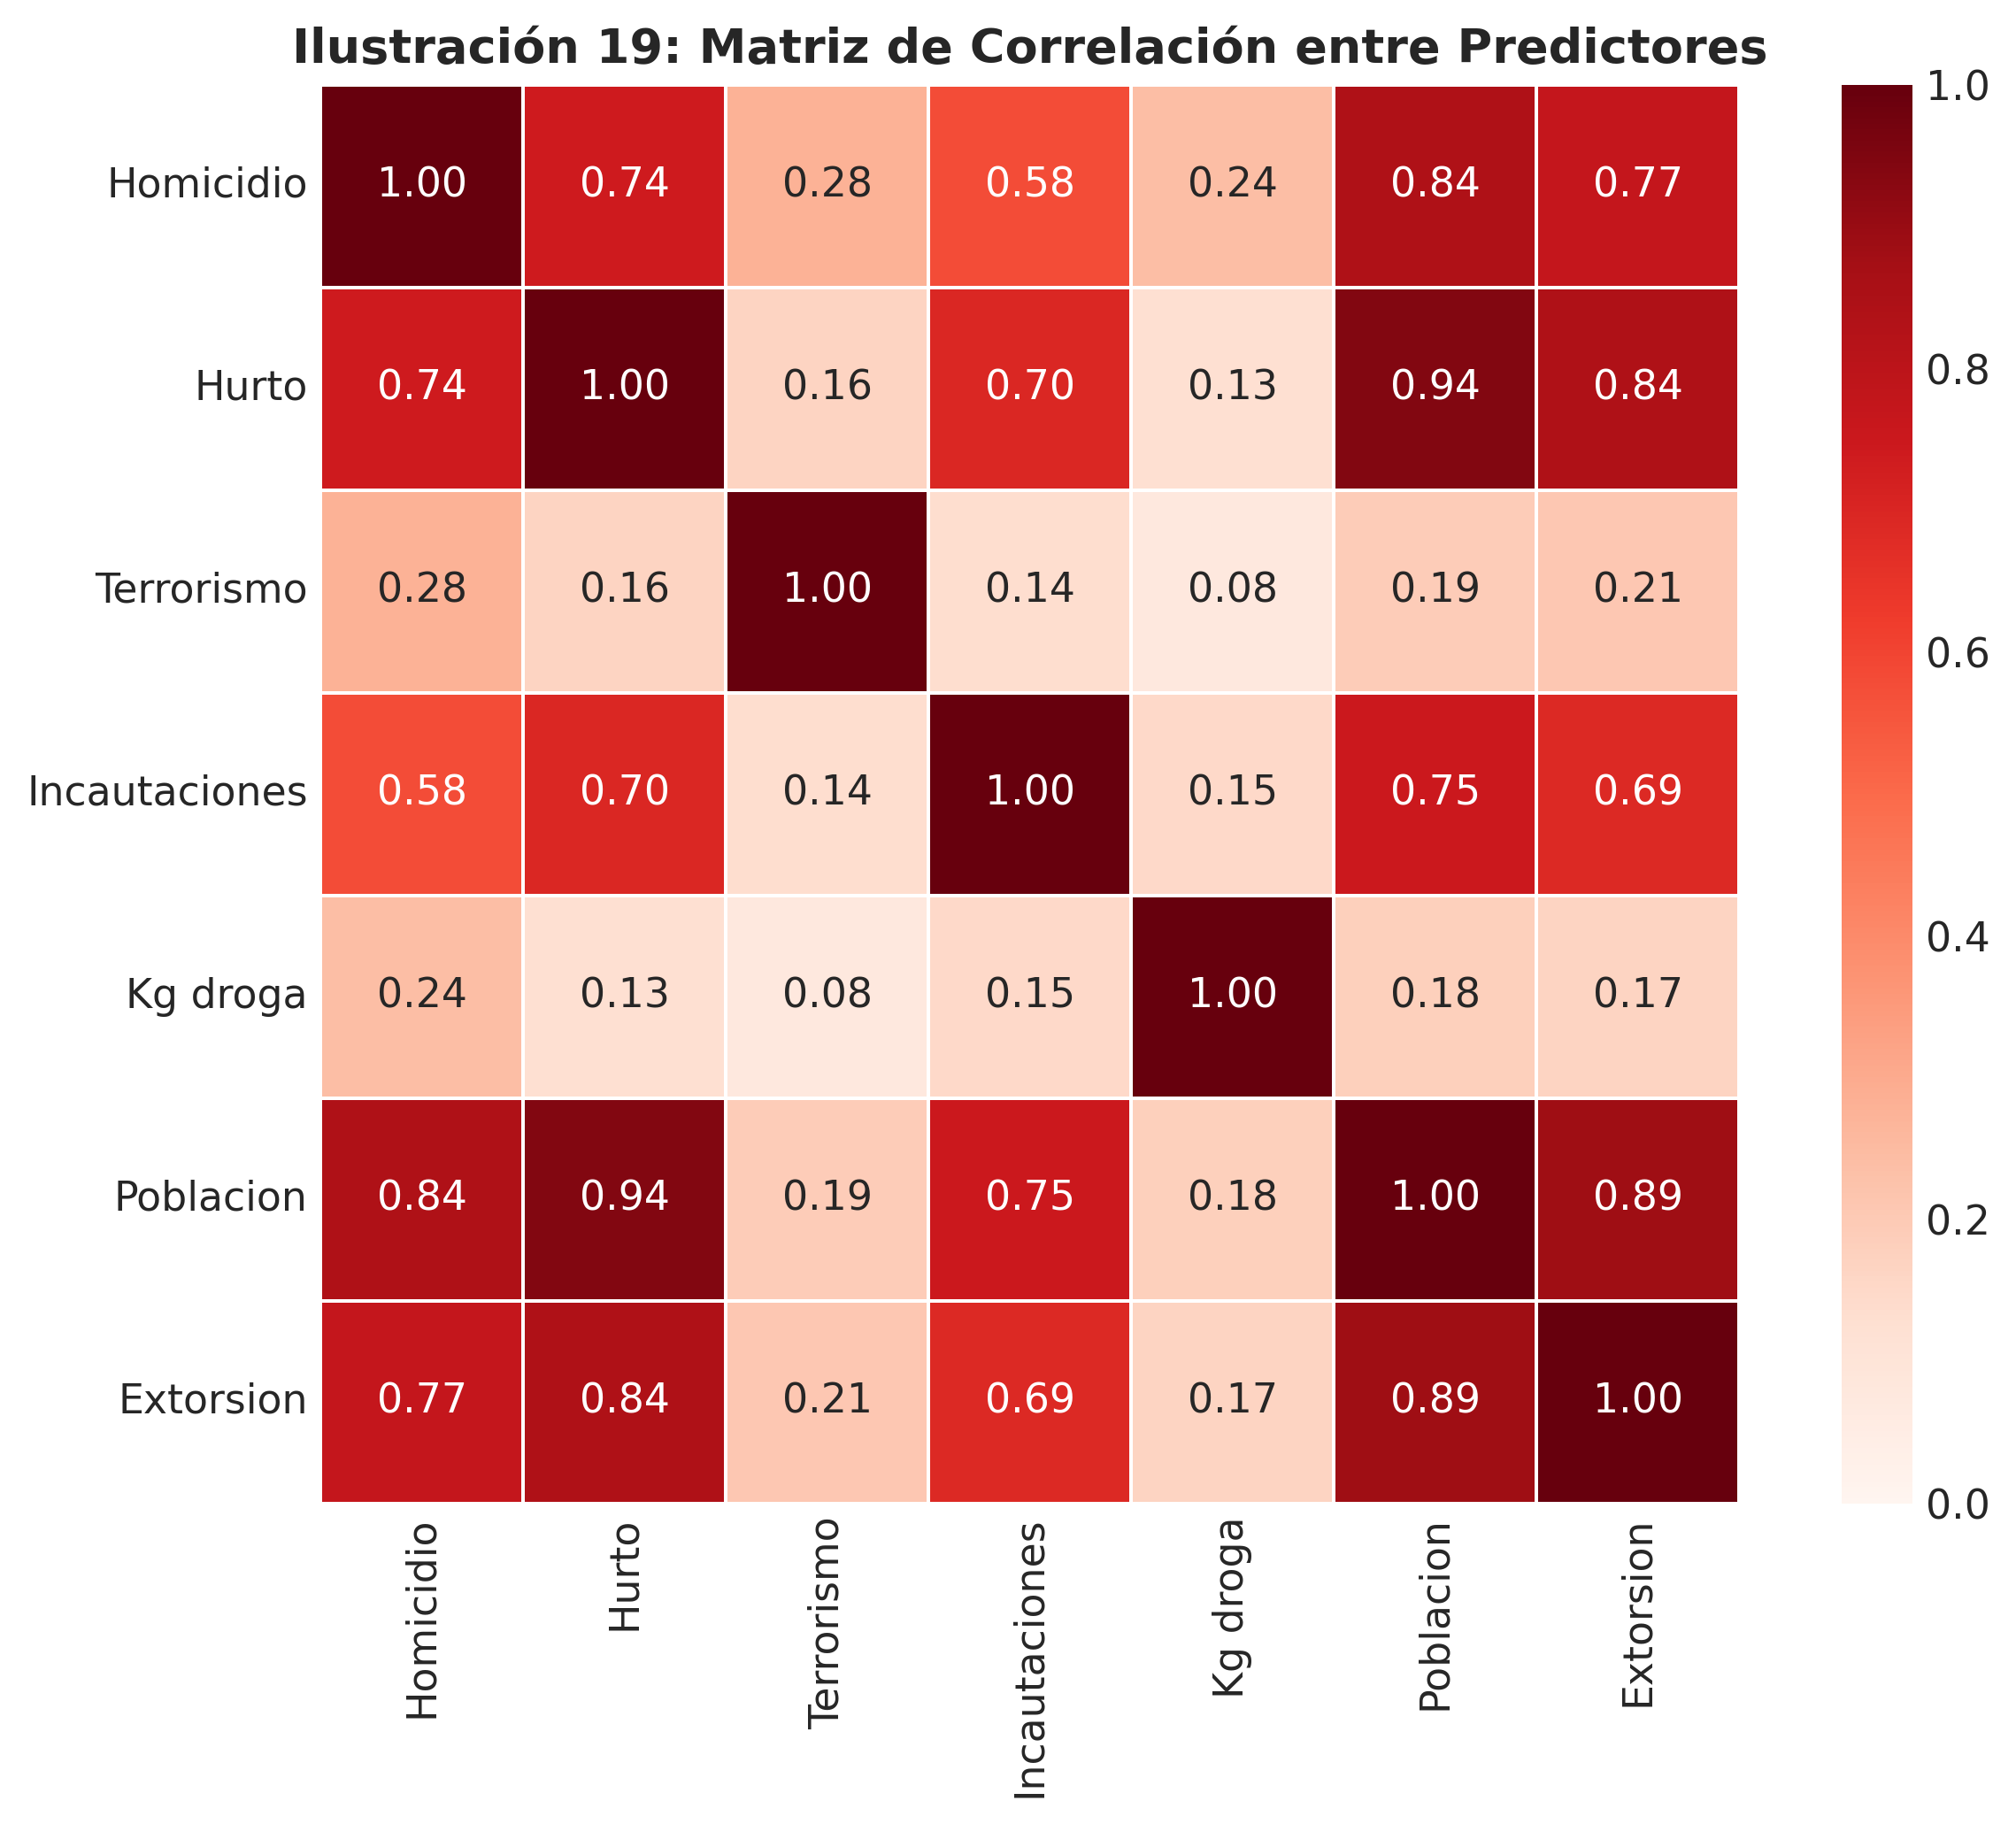

Guardado: ILUSTRACION_19_matriz_correlacion_predictores.png


In [15]:
# Variables del análisis
target   = 'total_extorsion'
num_vars = ['total_homicidio', 'total_hurto', 'total_terrorismo',
            'incautaciones_total', 'cantidad_total_kg', 'poblacion_total']

# ── Ilustración 18: Correlación de predictores con extorsión ─────────────────
correlaciones = df_gold[num_vars + [target]].corr()[target].drop(target).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#e74c3c' if v > 0.5 else '#3498db' if v > 0.2 else '#95a5a6' for v in correlaciones]
bars = ax.barh(correlaciones.index, correlaciones.values, color=colors, edgecolor='black', alpha=0.8)
for bar, val in zip(bars, correlaciones.values):
    ax.text(val + 0.01 if val >= 0 else val - 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=10)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlación de Pearson (r)', fontsize=12)
ax.set_title('Ilustración 18: Correlación de Variables con Extorsión', fontsize=13, fontweight='bold')
ax.set_xlim(-0.1, 1.05)
plt.tight_layout()
plt.savefig(f'{GRAFICOS_PATH}/ILUSTRACION_18_correlacion_con_extorsion.png', dpi=300, bbox_inches='tight')
plt.show()
print("Guardado: ILUSTRACION_18_correlacion_con_extorsion.png")

# ── Ilustración 19: Matriz de correlación entre predictores ──────────────────
df_vars = df_gold[num_vars + [target]].copy()
# Renombrar para etiquetas más cortas en el gráfico
rename_map = {
    'total_homicidio': 'Homicidio', 'total_hurto': 'Hurto',
    'total_terrorismo': 'Terrorismo', 'incautaciones_total': 'Incautaciones',
    'cantidad_total_kg': 'Kg droga', 'poblacion_total': 'Poblacion',
    'total_extorsion': 'Extorsion'
}
df_corr_matrix = df_vars.rename(columns=rename_map).corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df_corr_matrix, annot=True, fmt='.2f', cmap='Reds',
            vmin=0, vmax=1, ax=ax, square=True, linewidths=0.5)
ax.set_title('Ilustración 19: Matriz de Correlación entre Predictores', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{GRAFICOS_PATH}/ILUSTRACION_19_matriz_correlacion_predictores.png', dpi=300, bbox_inches='tight')
plt.show()
print("Guardado: ILUSTRACION_19_matriz_correlacion_predictores.png")


### Ilustración 20: Selección Recursiva de Variables (RFE)

Se evalúa cuántas variables son óptimas usando RFECV con validación cruzada temporal
(TimeSeriesSplit). Justificación del uso de TimeSeriesSplit en lugar de KFold estándar:
los datos tienen dependencia temporal, y usar splits aleatorios provocaría filtración
de información futura hacia el conjunto de entrenamiento (data leakage).


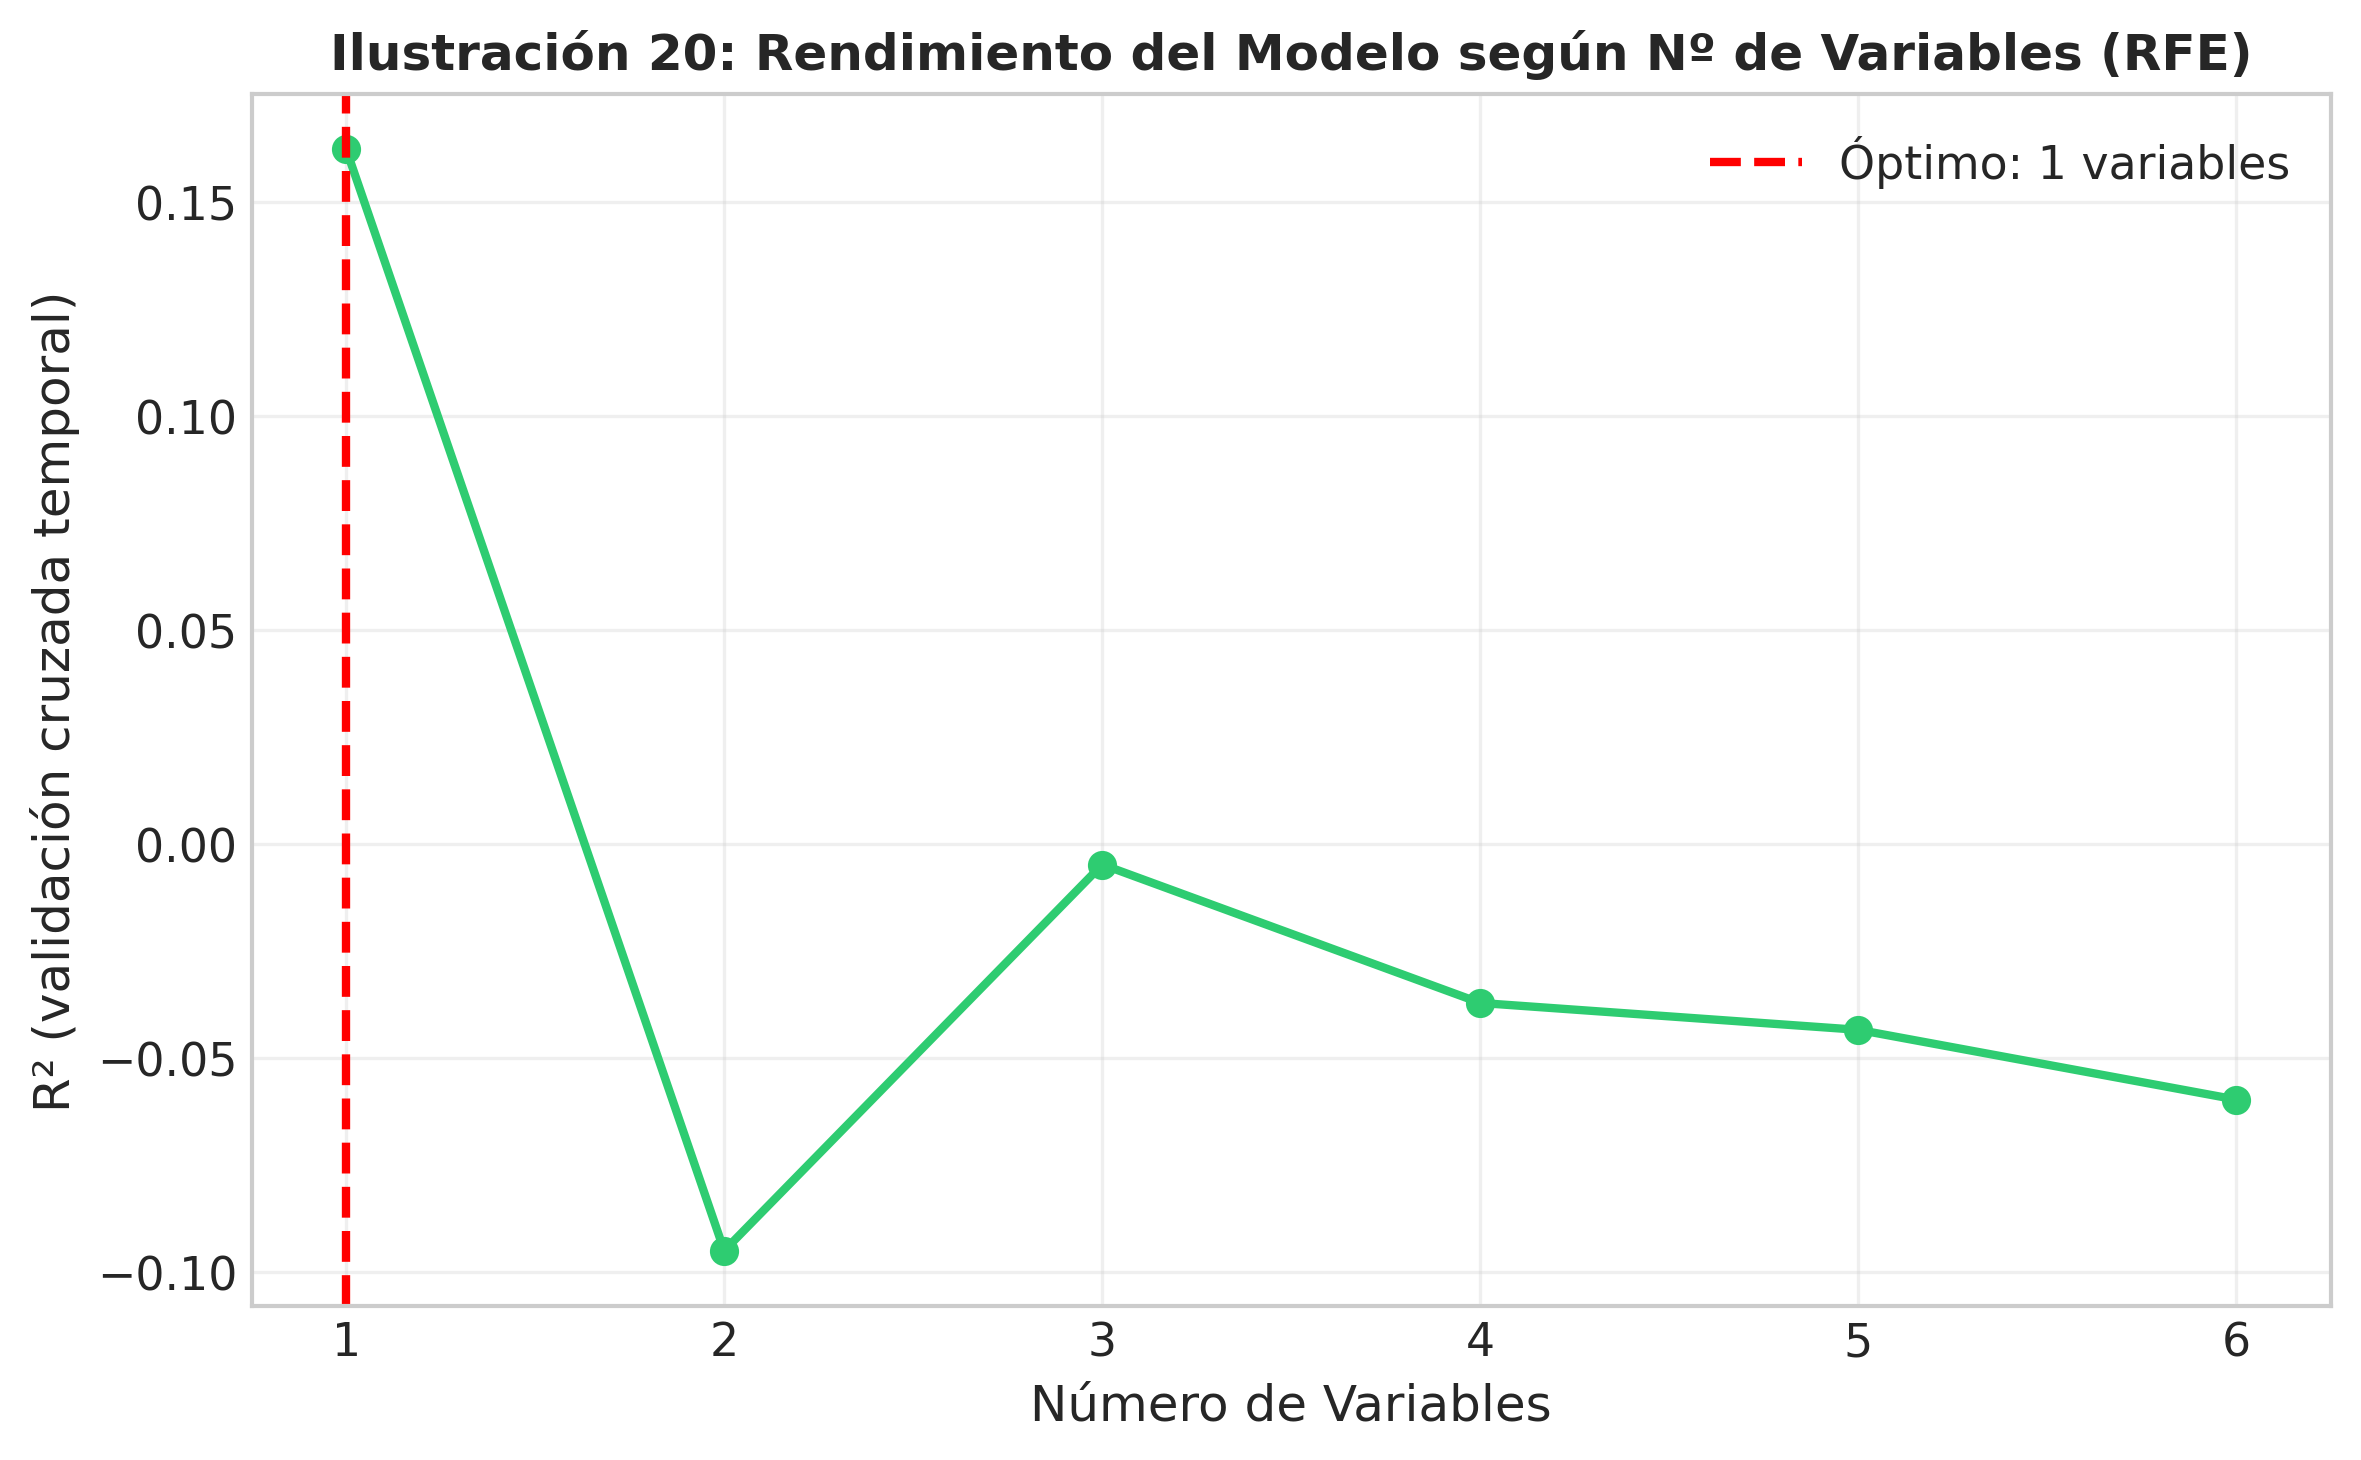

Guardado: ILUSTRACION_20_rendimiento_rfe.png
Variables optimas seleccionadas por RFE: ['poblacion_total']
R2 optimo (CV temporal): 0.1623


In [16]:
df_rfe = df_gold[num_vars + [target]].dropna()
X_rfe = df_rfe[num_vars].values
y_rfe = df_rfe[target].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_rfe)

# RFECV con Random Forest y validación temporal
rfecv = RFECV(
    estimator=RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1),
    step=1,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='r2',
    min_features_to_select=1
)
rfecv.fit(X_scaled, y_rfe)

n_features_range = range(1, len(num_vars) + 1)
mean_scores = rfecv.cv_results_['mean_test_score']

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(n_features_range, mean_scores, marker='o', linewidth=2, color='#2ecc71')
ax.axvline(rfecv.n_features_, color='red', linestyle='--', linewidth=2,
           label=f'Óptimo: {rfecv.n_features_} variables')
ax.set_xlabel('Número de Variables', fontsize=12)
ax.set_ylabel('R² (validación cruzada temporal)', fontsize=12)
ax.set_title('Ilustración 20: Rendimiento del Modelo según Nº de Variables (RFE)', fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xticks(list(n_features_range))
plt.tight_layout()
plt.savefig(f'{GRAFICOS_PATH}/ILUSTRACION_20_rendimiento_rfe.png', dpi=300, bbox_inches='tight')
plt.show()

variables_seleccionadas = [num_vars[i] for i, s in enumerate(rfecv.support_) if s]
print(f"Guardado: ILUSTRACION_20_rendimiento_rfe.png")
print(f"Variables optimas seleccionadas por RFE: {variables_seleccionadas}")
print(f"R2 optimo (CV temporal): {max(mean_scores):.4f}")


## 13. Resumen de Gráficos Generados


In [17]:
graficos = sorted(os.listdir(GRAFICOS_PATH))
print(f"Total gráficos en {GRAFICOS_PATH}/: {len(graficos)}")
for g in graficos:
    size_kb = os.path.getsize(os.path.join(GRAFICOS_PATH, g)) / 1024
    print(f"  {g:<60} {size_kb:>6.0f} KB")

Total gráficos en outputs/eda/graficos/: 16
  01_extorsion_tendencia_anual.png                                199 KB
  02_extorsion_tendencia_mensual.png                              238 KB
  03_extorsion_top_departamentos.png                              172 KB
  04_extorsion_boxplot_departamentos.png                          174 KB
  05_comparacion_delitos_temporal.png                             284 KB
  06_poblacion_urbana_rural.png                                   119 KB
  07_narcotrafico_evolucion.png                                   151 KB
  08_coca_vs_extorsion.png                                        178 KB
  09_poblacion_vs_extorsion.png                                   160 KB
  10_evolucion_cobertura_telecom.png                              209 KB
  11_matriz_correlacion_nacional.png                              121 KB
  12_matriz_correlacion_departamental.png                         145 KB
  14_terrorismo_evolucion.png                                     121 KB
  ILUST